## Group-level RSA (CWS vs. CWNS) on GLMsingle single-trial ROI RDMs

Compares CWS and CWNS on the per-subject, per-ROI crossnobis RDMs computed by `GLMsingle_rsa-roi.py`. Two complementary analyses:
1. **Model-fit comparison** (primary): correlate each subject's empirical RDM (per ROI) against categorical model RDMs (SNR level, syllable identity, speaker identity), then compare model-fit strength between groups via subject-level bootstrap.
2. **Direct RDM comparison** (descriptive): compare CWS-mean vs. CWNS-mean RDM per ROI directly, no categorical models involved.

**Multiple comparisons note (deliberate choice):** every ROI x model test below is independent, uncorrected across the 20 ROIs x up to 3 models -- consistent with the same "keep independent per-contrast FDR, document as deliberate" choice already made in `univariate_group-level.ipynb`.

In [1]:
import os
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import rsatoolbox

### Set parameters

In [2]:
bidsroot = os.path.join('/bgfs/bchandrasekaran/krs228/data/',
                        'SSP/',
                        'data_bids')
glmsingle_dir = os.path.join(bidsroot, 'derivatives', 'glmsingle')

RDM_METHOD = 'crossnobis'
NOISE_LEVEL_TAG = '0'  # matches GLMsingle_rsa-roi.py's --noise_level output tag ('all' or e.g. 'Q')

rdm_dir = os.path.join(glmsingle_dir, f'rsa-roi_glmsingle_rdmcalc-{RDM_METHOD}')
print('rdm_dir:', rdm_dir)

# Ordered all-L-then-all-R (mirrored, same relative region order in both halves) rather than
# per-network L/R blocks -- kept in sync with GLMsingle_mask-betas.py / GLMsingle_rsa-roi.py.
CORTICAL_ROI_LIST = [
    'L-HG', 'L-PT', 'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri', 'L-SMGa', 'L-SMGp', 'L-Ang',
    'R-HG', 'R-PT', 'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri', 'R-SMGa', 'R-SMGp', 'R-Ang',
]

# base region order (no hemisphere prefix), for the hemisphere-hue group-specific plots below
BASE_REGION_ORDER = [roi.split('-', 1)[1] for roi in CORTICAL_ROI_LIST if roi.startswith('L-')]

N_BOOT = 10000
RNG = np.random.default_rng(0)

out_dir = os.path.join(glmsingle_dir, 'rsa-group_glmsingle')
os.makedirs(out_dir, exist_ok=True)

rdm_dir: /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/glmsingle/rsa-roi_glmsingle_rdmcalc-crossnobis


### Load participants and group membership

In [3]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# case-/whitespace-normalized group comparison -- same fix already applied in
# univariate_group-level.ipynb, since participants.tsv's group column has been observed with
# inconsistent casing (e.g. 'CWS' vs 'cws').
group_norm = participants_df.group.str.strip().str.lower()
sub_list_cwns_all = list(participants_df.participant_id[group_norm == 'control'])
sub_list_cws_all = list(participants_df.participant_id[group_norm == 'cws'])

# restrict to subjects that actually have an RDM file -- not every subject in participants.tsv
# has usable GLMsingle output (e.g. single-run subjects only get the degraded TYPEB estimate,
# which GLMsingle_mask-betas.py already refuses to mask for RSA).
rdm_fpaths = sorted(glob(os.path.join(rdm_dir, f'sub-*_glmsingle_cortical_{RDM_METHOD}_noiselevel-{NOISE_LEVEL_TAG}_rdms.hdf5')))
subs_with_rdms = set()
for f in rdm_fpaths:
    fname = os.path.basename(f)
    sub_id = fname.split('_')[0].replace('sub-', '')
    subs_with_rdms.add(f'sub-{sub_id}')

sub_list_cwns = [s for s in sub_list_cwns_all if s in subs_with_rdms]
sub_list_cws = [s for s in sub_list_cws_all if s in subs_with_rdms]

print(f'{len(rdm_fpaths)} RDM files found')
print(f'CWNS: {len(sub_list_cwns)}/{len(sub_list_cwns_all)} have RDMs')
print(f'CWS: {len(sub_list_cws)}/{len(sub_list_cws_all)} have RDMs')

30 RDM files found
CWNS: 23/43 have RDMs
CWS: 7/14 have RDMs


### Load each subject's RDMs

In [4]:
def load_subject_rdms(sub_id):
    fpath = os.path.join(rdm_dir, f'{sub_id}_glmsingle_cortical_{RDM_METHOD}_noiselevel-{NOISE_LEVEL_TAG}_rdms.hdf5')
    # NOTE: rsatoolbox's exact load function/path is not independently confirmed against an
    # installed version (none available locally) -- rsatoolbox.rdm.rdms.load_rdm is the
    # symmetric counterpart to rsatoolbox.rdm.rdms.concat, which GLMsingle_rsa-roi.py already
    # uses successfully to save these files. Confirm this exact call on first real run; if it
    # differs, this is the one line to fix.
    return rsatoolbox.rdm.rdms.load_rdm(fpath, file_type='hdf5')


all_subs = sub_list_cwns + sub_list_cws
subject_rdms = {}
for sub_id in all_subs:
    subject_rdms[sub_id] = load_subject_rdms(sub_id)

print(f'Loaded RDMs for {len(subject_rdms)} subjects')

Loaded RDMs for 30 subjects


### Categorical model RDMs (SNR / syllable / speaker)

In [5]:
def build_categorical_model_rdms(pattern_labels):
    """Build SNR/syllable/speaker categorical model RDMs (0 if the two stimuli match on that
    dimension, 1 if they differ), sized and ORDERED to exactly match `pattern_labels` -- the
    actual condition order taken from a loaded empirical RDM's pattern_descriptors, not a
    freshly re-derived list. The model and empirical RDMs' row/column order must match exactly
    for rsatoolbox.rdm.compare() to compare like-for-like conditions.

    Each condition label is expected to be 'SYLLABLE_SPEAKER_NOISELEVEL' (e.g. 'BA_F1_Q'), per
    GLMsingle_first-level.py's build_condition_labels(). Fixes the copy-paste bug in the old
    group_level_rsa_searchlight_WIP.ipynb, where the talker/speaker model RDM was assigned into
    the syllable_rdms variable instead of its own.
    """
    n = len(pattern_labels)
    parsed = [label.split('_') for label in pattern_labels]
    for p in parsed:
        assert len(p) == 3, f"expected 'syllable_speaker_noiselevel', got {p!r}"
    syllables = [p[0] for p in parsed]
    speakers = [p[1] for p in parsed]
    noise_levels = [p[2] for p in parsed]

    model_rdms = {}
    model_rdms['syllable'] = np.array([[0 if syllables[i] == syllables[j] else 1
                                        for j in range(n)] for i in range(n)])
    model_rdms['speaker'] = np.array([[0 if speakers[i] == speakers[j] else 1
                                       for j in range(n)] for i in range(n)])

    # SNR model is degenerate (all-zero, no variance to model) if every trial shares the same
    # noise level -- e.g. a noiselevel-restricted (Q-only) RDM. Skip it automatically rather
    # than including a meaningless all-zero model, instead of hardcoding per noise-level-tag.
    if len(set(noise_levels)) > 1:
        model_rdms['snr'] = np.array([[0 if noise_levels[i] == noise_levels[j] else 1
                                       for j in range(n)] for i in range(n)])
    else:
        print(f'Only one noise level ({noise_levels[0]}) present -- skipping the degenerate SNR model.')

    return model_rdms


# pattern order is assumed identical across subjects/ROIs (same fixed condition design for
# everyone) -- take it from the first subject's first ROI as the reference.
example_rdms = next(iter(subject_rdms.values()))
example_roi_rdm = example_rdms.subset('ROI', CORTICAL_ROI_LIST[0])
# NOTE: pattern_descriptors key name ('stimulus') matches the `descriptor='stimulus'` used when
# building these RDMs in GLMsingle_rsa-roi.py's calc_rdm() call -- confirm on first real run.
pattern_labels = list(example_roi_rdm.pattern_descriptors['stimulus'])
print(f'{len(pattern_labels)} conditions per RDM:', pattern_labels[:5], '...')

categorical_model_rdms = build_categorical_model_rdms(pattern_labels)
print('models built:', list(categorical_model_rdms.keys()))

16 conditions per RDM: ['BA_F1_0', 'BA_F2_0', 'BA_M1_0', 'BA_M2_0', 'DA_F1_0'] ...
Only one noise level (0) present -- skipping the degenerate SNR model.
models built: ['syllable', 'speaker']


#### QC: visualize the categorical model RDMs

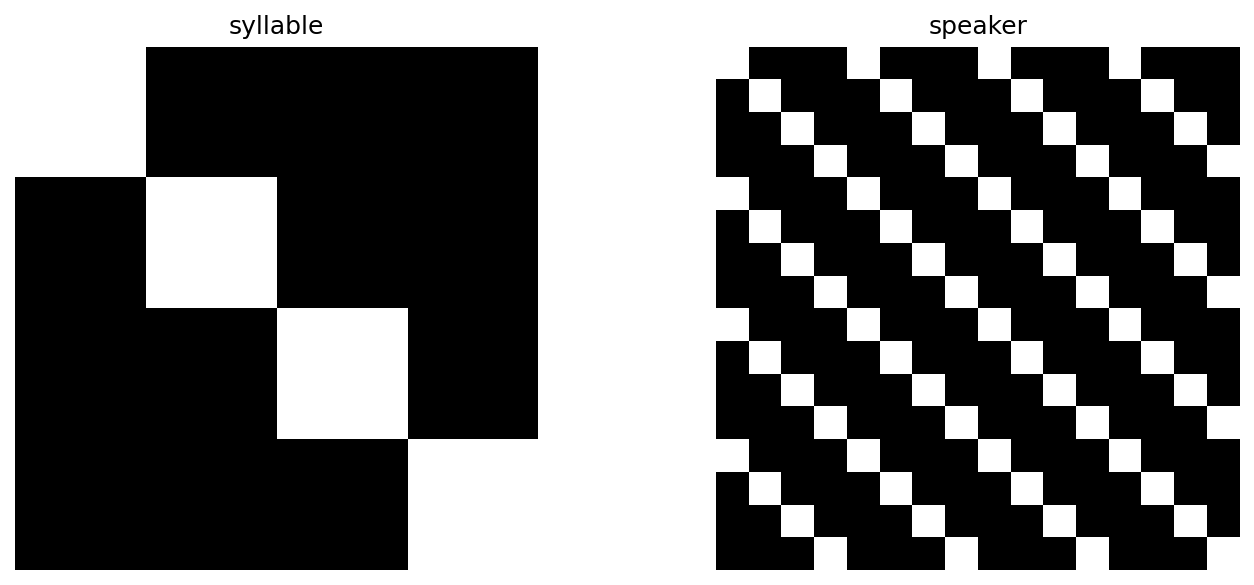

In [6]:
fig, axes = plt.subplots(1, len(categorical_model_rdms), figsize=(5 * len(categorical_model_rdms), 4), dpi=150)
if len(categorical_model_rdms) == 1:
    axes = [axes]
for ax, (name, mat) in zip(axes, categorical_model_rdms.items()):
    sns.heatmap(mat, cmap='Greys', square=True, cbar=False, xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title(name)
fig.tight_layout()

### Per-subject, per-ROI model-fit scalars

In [7]:
def get_roi_rdm_vector(rdms_obj, roi):
    """Extract the single dissimilarity vector for one ROI from a subject's full RDMs object.
    NOTE: .get_vectors() is rsatoolbox's compressed (upper-triangular) vector form -- confirm
    this exact method name on first real run; .get_matrices() is the square-matrix alternative
    if this doesn't match the installed rsatoolbox version.
    """
    roi_rdm = rdms_obj.subset('ROI', roi)
    return roi_rdm.get_vectors()[0]


model_fit_rows = []
for sub_id, rdms_obj in subject_rdms.items():
    group = 'CWNS' if sub_id in sub_list_cwns else 'CWS'
    for roi in CORTICAL_ROI_LIST:
        try:
            roi_rdm = rdms_obj.subset('ROI', roi)
        except Exception as e:
            print(f'Could not extract ROI {roi} for {sub_id}: {e}')
            continue

        for model_name, model_mat in categorical_model_rdms.items():
            model_rdm_obj = rsatoolbox.rdm.RDMs(
                model_mat[np.newaxis, :, :],
                rdm_descriptors={'model': [model_name]},
                dissimilarity_measure='Euclidean',
            )
            # NOTE: rsatoolbox.rdm.compare()'s exact signature/return shape (scalar vs. 1x1
            # array) is not independently confirmed against an installed version -- adjust the
            # indexing below if this doesn't match on first real run.
            fit = rsatoolbox.rdm.compare(roi_rdm, model_rdm_obj, method='corr')
            fit_value = np.asarray(fit).flatten()[0]

            model_fit_rows.append({
                'subject_id': sub_id, 'group': group, 'ROI': roi,
                'model': model_name, 'fit': fit_value,
            })

model_fit_df = pd.DataFrame(model_fit_rows)
model_fit_df.to_csv(os.path.join(out_dir, f'model_fit_scalars_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
model_fit_df.head()

,subject_id,group,ROI,model,fit
0,sub-SSP008,CWNS,L-HG,syllable,0.013479
1,sub-SSP008,CWNS,L-HG,speaker,-0.031095
2,sub-SSP008,CWNS,L-PT,syllable,0.004245
3,sub-SSP008,CWNS,L-PT,speaker,0.001828
4,sub-SSP008,CWNS,L-PP,syllable,-0.069994


### Group comparison: subject-level bootstrap

In [8]:
def bootstrap_group_difference(values_a, values_b, n_boot=N_BOOT, rng=RNG):
    """Subject-level bootstrap test for a difference in means between two groups. Resamples
    subjects WITH replacement WITHIN each group (not across groups), computes the group-mean
    difference (a - b) each iteration, and derives a two-sided empirical p-value from how often
    the null-centered bootstrap distribution is at least as extreme as the observed difference.
    Operates purely on whatever scalars are passed in -- agnostic to how they were derived,
    including from GLMsingle-based RDMs (confirmed compatible per the earlier discussion: the
    bootstrap is downstream of and independent from how the single-trial patterns were estimated).
    """
    values_a = np.asarray(values_a)
    values_b = np.asarray(values_b)
    observed_diff = values_a.mean() - values_b.mean()

    boot_diffs = np.empty(n_boot)
    for i in range(n_boot):
        resampled_a = rng.choice(values_a, size=len(values_a), replace=True)
        resampled_b = rng.choice(values_b, size=len(values_b), replace=True)
        boot_diffs[i] = resampled_a.mean() - resampled_b.mean()

    ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])
    null_centered = boot_diffs - boot_diffs.mean()
    p_value = np.mean(np.abs(null_centered) >= np.abs(observed_diff))

    return {'observed_diff': observed_diff, 'ci_low': ci_low, 'ci_high': ci_high, 'p_value': p_value}


group_comparison_rows = []
for roi in CORTICAL_ROI_LIST:
    for model_name in categorical_model_rdms.keys():
        subset = model_fit_df[(model_fit_df.ROI == roi) & (model_fit_df.model == model_name)]
        cws_vals = subset.loc[subset.group == 'CWS', 'fit'].values
        cwns_vals = subset.loc[subset.group == 'CWNS', 'fit'].values
        if len(cws_vals) < 2 or len(cwns_vals) < 2:
            print(f'Skipping {roi}/{model_name}: not enough subjects per group')
            continue

        result = bootstrap_group_difference(cws_vals, cwns_vals)
        group_comparison_rows.append({
            'ROI': roi, 'model': model_name,
            'n_cws': len(cws_vals), 'n_cwns': len(cwns_vals),
            **result,
        })

group_comparison_df = pd.DataFrame(group_comparison_rows)
group_comparison_df.to_csv(os.path.join(out_dir, f'group_comparison_bootstrap_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
group_comparison_df.sort_values('p_value').head(20)

,ROI,model,n_cws,n_cwns,observed_diff,ci_low,ci_high,p_value
34,R-SMGa,syllable,7,23,-0.062766,-0.114431,-0.020702,0.0105
26,R-STGp,syllable,7,23,-0.066817,-0.120627,-0.009392,0.0198
31,R-ParsOp,speaker,7,23,-0.044801,-0.085854,-0.003148,0.0326
28,R-STGa,syllable,7,23,-0.043335,-0.089261,0.000965,0.0619
7,L-STGp,speaker,7,23,-0.045947,-0.096825,0.001443,0.0678
35,R-SMGa,speaker,7,23,0.037478,-0.005685,0.080717,0.0901
20,R-HG,syllable,7,23,-0.041492,-0.095899,0.013129,0.1409
2,L-PT,syllable,7,23,0.041178,-0.014730,0.101110,0.1593
37,R-SMGp,speaker,7,23,0.048719,-0.016414,0.121583,0.1696
32,R-ParsTri,syllable,7,23,-0.034497,-0.083690,0.020048,0.1904


### Within-group significance testing (which ROIs are significant for which models?)

In addition to the between-group comparison above, test **within each group separately**: is the mean model-fit significantly different from 0 (i.e. is this categorical distinction actually represented in this ROI, for this group)? Same subject-level bootstrap philosophy, applied as a one-sample test instead of a two-sample difference test. Same "independent per-ROI/model, uncorrected" multiple-comparisons stance as the between-group test.

In [9]:
def bootstrap_one_sample(values, null_value=0, n_boot=N_BOOT, rng=RNG):
    """Subject-level bootstrap one-sample test: is the mean of `values` significantly
    different from `null_value` (typically 0, i.e. no representational correlation with the
    model)? Resamples subjects with replacement within a single group, builds an empirical
    distribution of the mean, and derives a two-sided p-value/CI for whether the observed mean
    differs from null_value.
    """
    values = np.asarray(values)
    observed_mean = values.mean()

    boot_means = np.empty(n_boot)
    for i in range(n_boot):
        resampled = rng.choice(values, size=len(values), replace=True)
        boot_means[i] = resampled.mean()

    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    # center the bootstrap distribution at null_value (removing its own sampling bias first) to
    # test how extreme the observed mean is under a null of "no effect"
    null_centered = boot_means - boot_means.mean() + null_value
    p_value = np.mean(np.abs(null_centered - null_value) >= np.abs(observed_mean - null_value))

    return {'observed_mean': observed_mean, 'ci_low': ci_low, 'ci_high': ci_high, 'p_value': p_value}


within_group_rows = []
for roi in CORTICAL_ROI_LIST:
    for model_name in categorical_model_rdms.keys():
        subset = model_fit_df[(model_fit_df.ROI == roi) & (model_fit_df.model == model_name)]
        for group_name in ['CWS', 'CWNS']:
            vals = subset.loc[subset.group == group_name, 'fit'].values
            if len(vals) < 2:
                print(f'Skipping {roi}/{model_name}/{group_name}: not enough subjects')
                continue

            result = bootstrap_one_sample(vals)
            within_group_rows.append({
                'ROI': roi, 'model': model_name, 'group': group_name, 'n': len(vals),
                **result,
            })

within_group_significance_df = pd.DataFrame(within_group_rows)
within_group_significance_df.to_csv(
    os.path.join(out_dir, f'within_group_significance_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
within_group_significance_df.sort_values('p_value').head(20)

,ROI,model,group,n,observed_mean,ci_low,ci_high,p_value
52,R-STGp,syllable,CWS,7,-0.068423,-0.106196,-0.026024,0.0010
69,R-SMGa,syllable,CWNS,23,0.026097,0.004900,0.047609,0.0157
12,L-STGp,syllable,CWS,7,0.011489,0.000427,0.020135,0.0205
40,R-HG,syllable,CWS,7,-0.054081,-0.100913,-0.005255,0.0227
71,R-SMGa,speaker,CWNS,23,-0.032020,-0.063288,-0.005732,0.0287
10,L-PP,speaker,CWS,7,-0.031522,-0.058491,0.000154,0.0323
14,L-STGp,speaker,CWS,7,-0.038777,-0.078335,-0.002149,0.0484
62,R-ParsOp,speaker,CWS,7,-0.032654,-0.066672,0.000454,0.0552
54,R-STGp,speaker,CWS,7,0.039583,-0.007851,0.077911,0.0684
68,R-SMGa,syllable,CWS,7,-0.036669,-0.083685,-0.001625,0.0830


### Direct RDM comparison (descriptive complement)

In [10]:
def bootstrap_rdm_distance(rdm_vectors_a, rdm_vectors_b, n_boot=N_BOOT, rng=RNG):
    """Bootstrap CI for whether two groups' mean RDMs differ, using 1 - Pearson correlation
    between the two group-mean RDM vectors as the dissimilarity-of-dissimilarities statistic.
    Descriptive complement to the categorical-model-fit comparison above -- no categorical
    models involved, just "is the overall similarity structure different between groups."
    Doesn't have a natural null-hypothesis p-value the way a mean-difference bootstrap does;
    report the CI and whether it's close to 0 (little difference) or not.
    """
    rdm_vectors_a = np.vstack(rdm_vectors_a)
    rdm_vectors_b = np.vstack(rdm_vectors_b)

    def rdm_corr_distance(vecs_a, vecs_b):
        mean_a = vecs_a.mean(axis=0)
        mean_b = vecs_b.mean(axis=0)
        r = np.corrcoef(mean_a, mean_b)[0, 1]
        return 1 - r

    observed_distance = rdm_corr_distance(rdm_vectors_a, rdm_vectors_b)

    idx_a = np.arange(len(rdm_vectors_a))
    idx_b = np.arange(len(rdm_vectors_b))
    boot_distances = np.empty(n_boot)
    for i in range(n_boot):
        resampled_a = rdm_vectors_a[rng.choice(idx_a, size=len(idx_a), replace=True)]
        resampled_b = rdm_vectors_b[rng.choice(idx_b, size=len(idx_b), replace=True)]
        boot_distances[i] = rdm_corr_distance(resampled_a, resampled_b)

    ci_low, ci_high = np.percentile(boot_distances, [2.5, 97.5])
    return {'observed_distance': observed_distance, 'ci_low': ci_low, 'ci_high': ci_high}


mean_rdm_rows = []
for roi in CORTICAL_ROI_LIST:
    cws_vectors = [get_roi_rdm_vector(subject_rdms[s], roi) for s in sub_list_cws if s in subject_rdms]
    cwns_vectors = [get_roi_rdm_vector(subject_rdms[s], roi) for s in sub_list_cwns if s in subject_rdms]
    if len(cws_vectors) < 2 or len(cwns_vectors) < 2:
        continue

    result = bootstrap_rdm_distance(cws_vectors, cwns_vectors)
    mean_rdm_rows.append({'ROI': roi, **result})

mean_rdm_df = pd.DataFrame(mean_rdm_rows)
mean_rdm_df.to_csv(os.path.join(out_dir, f'mean_rdm_comparison_noiselevel-{NOISE_LEVEL_TAG}.csv'), index=False)
mean_rdm_df.sort_values('observed_distance', ascending=False)

,ROI,observed_distance,ci_low,ci_high
18,R-SMGp,1.228892,0.775352,1.307235
8,L-SMGp,1.179929,0.838065,1.201925
12,R-PP,1.175782,0.860499,1.287504
7,L-SMGa,1.174938,0.971133,1.329609
14,R-STGa,1.085530,0.874464,1.188627
4,L-STGa,1.002419,0.803777,1.158188
1,L-PT,1.002394,0.750330,1.175499
9,L-Ang,0.981948,0.772073,1.111821
11,R-PT,0.953580,0.690542,1.223992
3,L-STGp,0.949028,0.697426,1.220665


#### QC: visualize CWS-mean vs. CWNS-mean RDM for one ROI

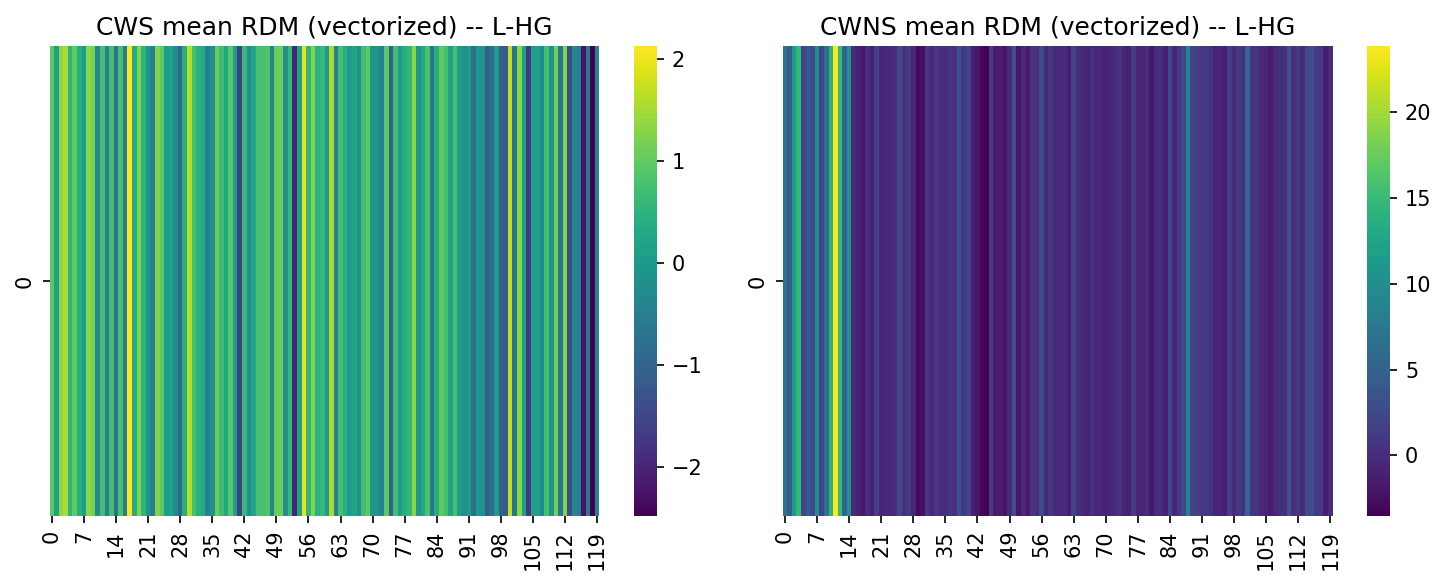

In [11]:
example_roi = CORTICAL_ROI_LIST[0]
cws_vectors = [get_roi_rdm_vector(subject_rdms[s], example_roi) for s in sub_list_cws if s in subject_rdms]
cwns_vectors = [get_roi_rdm_vector(subject_rdms[s], example_roi) for s in sub_list_cwns if s in subject_rdms]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
sns.heatmap(np.vstack(cws_vectors).mean(axis=0).reshape(1, -1), cmap='viridis', ax=axes[0], cbar=True)
axes[0].set_title(f'CWS mean RDM (vectorized) -- {example_roi}')
sns.heatmap(np.vstack(cwns_vectors).mean(axis=0).reshape(1, -1), cmap='viridis', ax=axes[1], cbar=True)
axes[1].set_title(f'CWNS mean RDM (vectorized) -- {example_roi}')
fig.tight_layout()

### Boxplot + stripplot per model

Mirrors `fMRI_auditory-category-learning/06_univariate/group_level_all_ROI.ipynb`'s
`plot_roi_box_plots` pattern: stripplot + boxplot overlay, both with fill stripped to
transparent and outlined in each hue group's assigned color instead (not a default/neutral
outline). ROIs with a significant within-group effect (p < 0.05, from the bootstrap one-sample
test above) get an asterisk above them, with headroom added so it doesn't collide with the title.

Two variants:
1. **Combined** (`x=ROI` for all 20 ROIs, `hue=group`) -- one figure per model. Asterisk marks a
   ROI if *either* group is significant there (not group-specific).
2. **Group-specific** (`x=region` -- base ROI name, hemisphere prefix stripped -- `hue=hemisphere`)
   -- one figure per (model, group), fewer x-categories (10 base regions instead of 20 ROIs).
   Asterisks are placed over the specific L or R box (using seaborn's dodge offset), so
   significance is shown per-hemisphere, not pooled across both.

/scratch/slurm-10617510/ipykernel_3726586/3855817025.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/scratch/slurm-10617510/ipykernel_3726586/3855817025.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/scratch/slurm-10617510/ipykernel_3726586/3855817025.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/scratch/slurm-10617510/ipykernel_3726586/3855817025.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), r

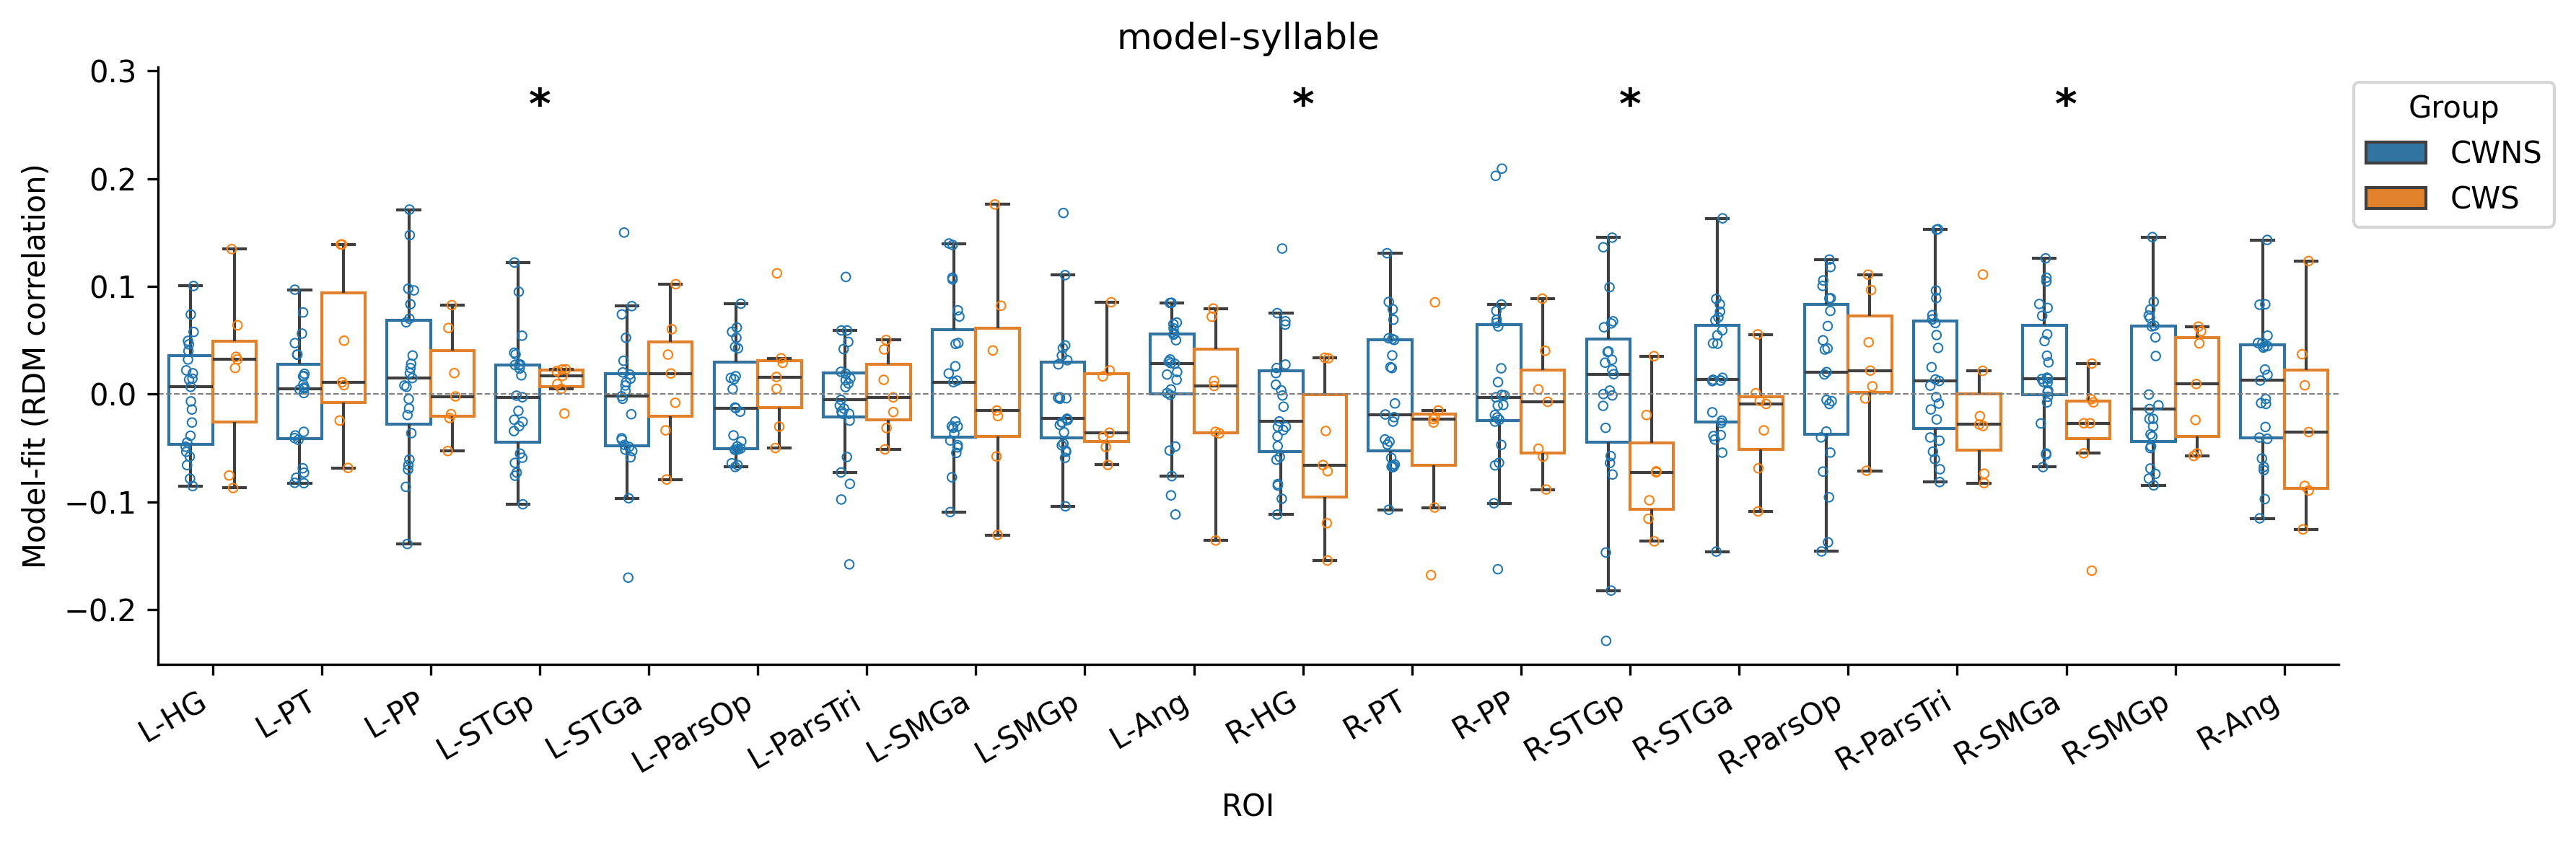

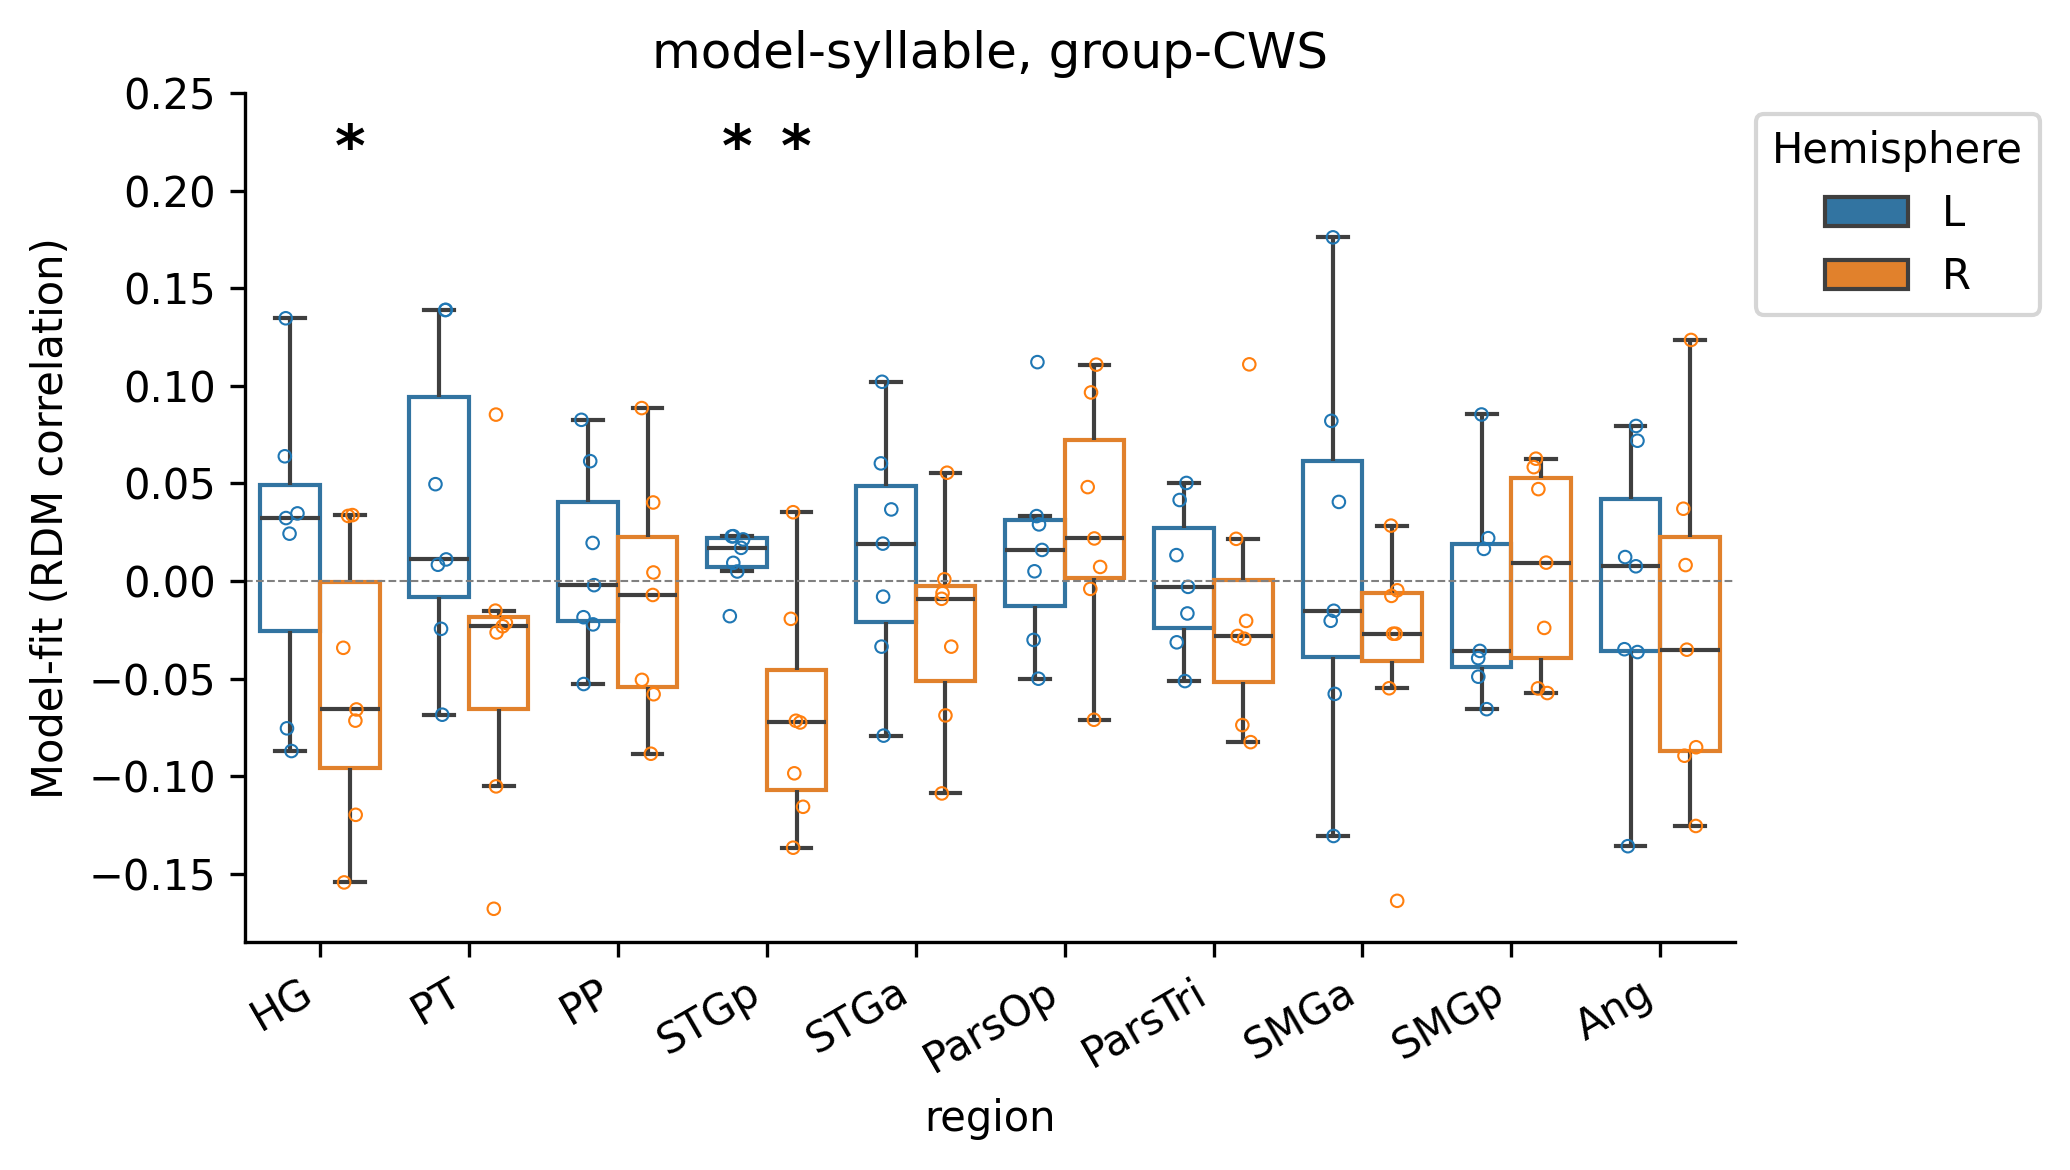

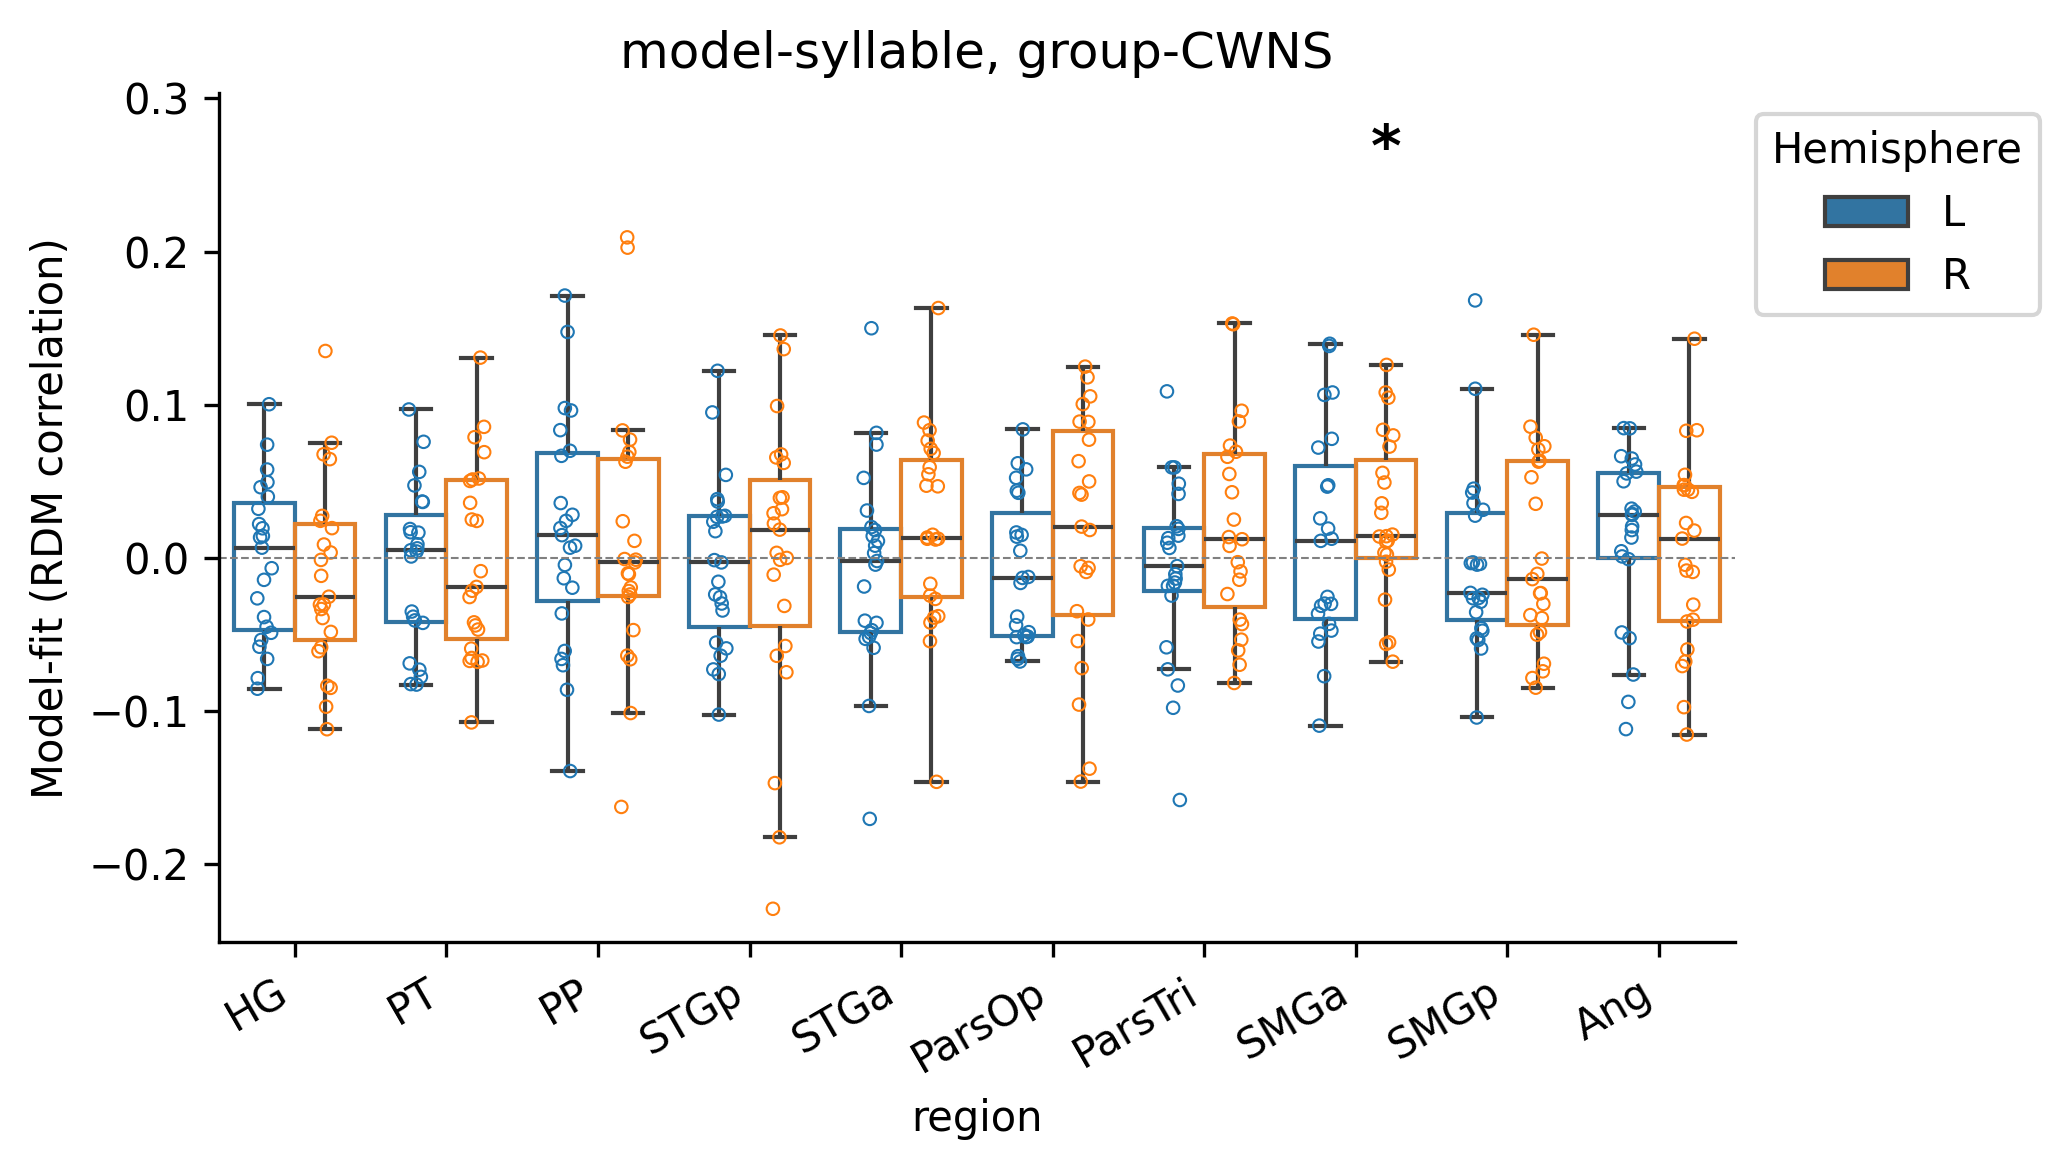

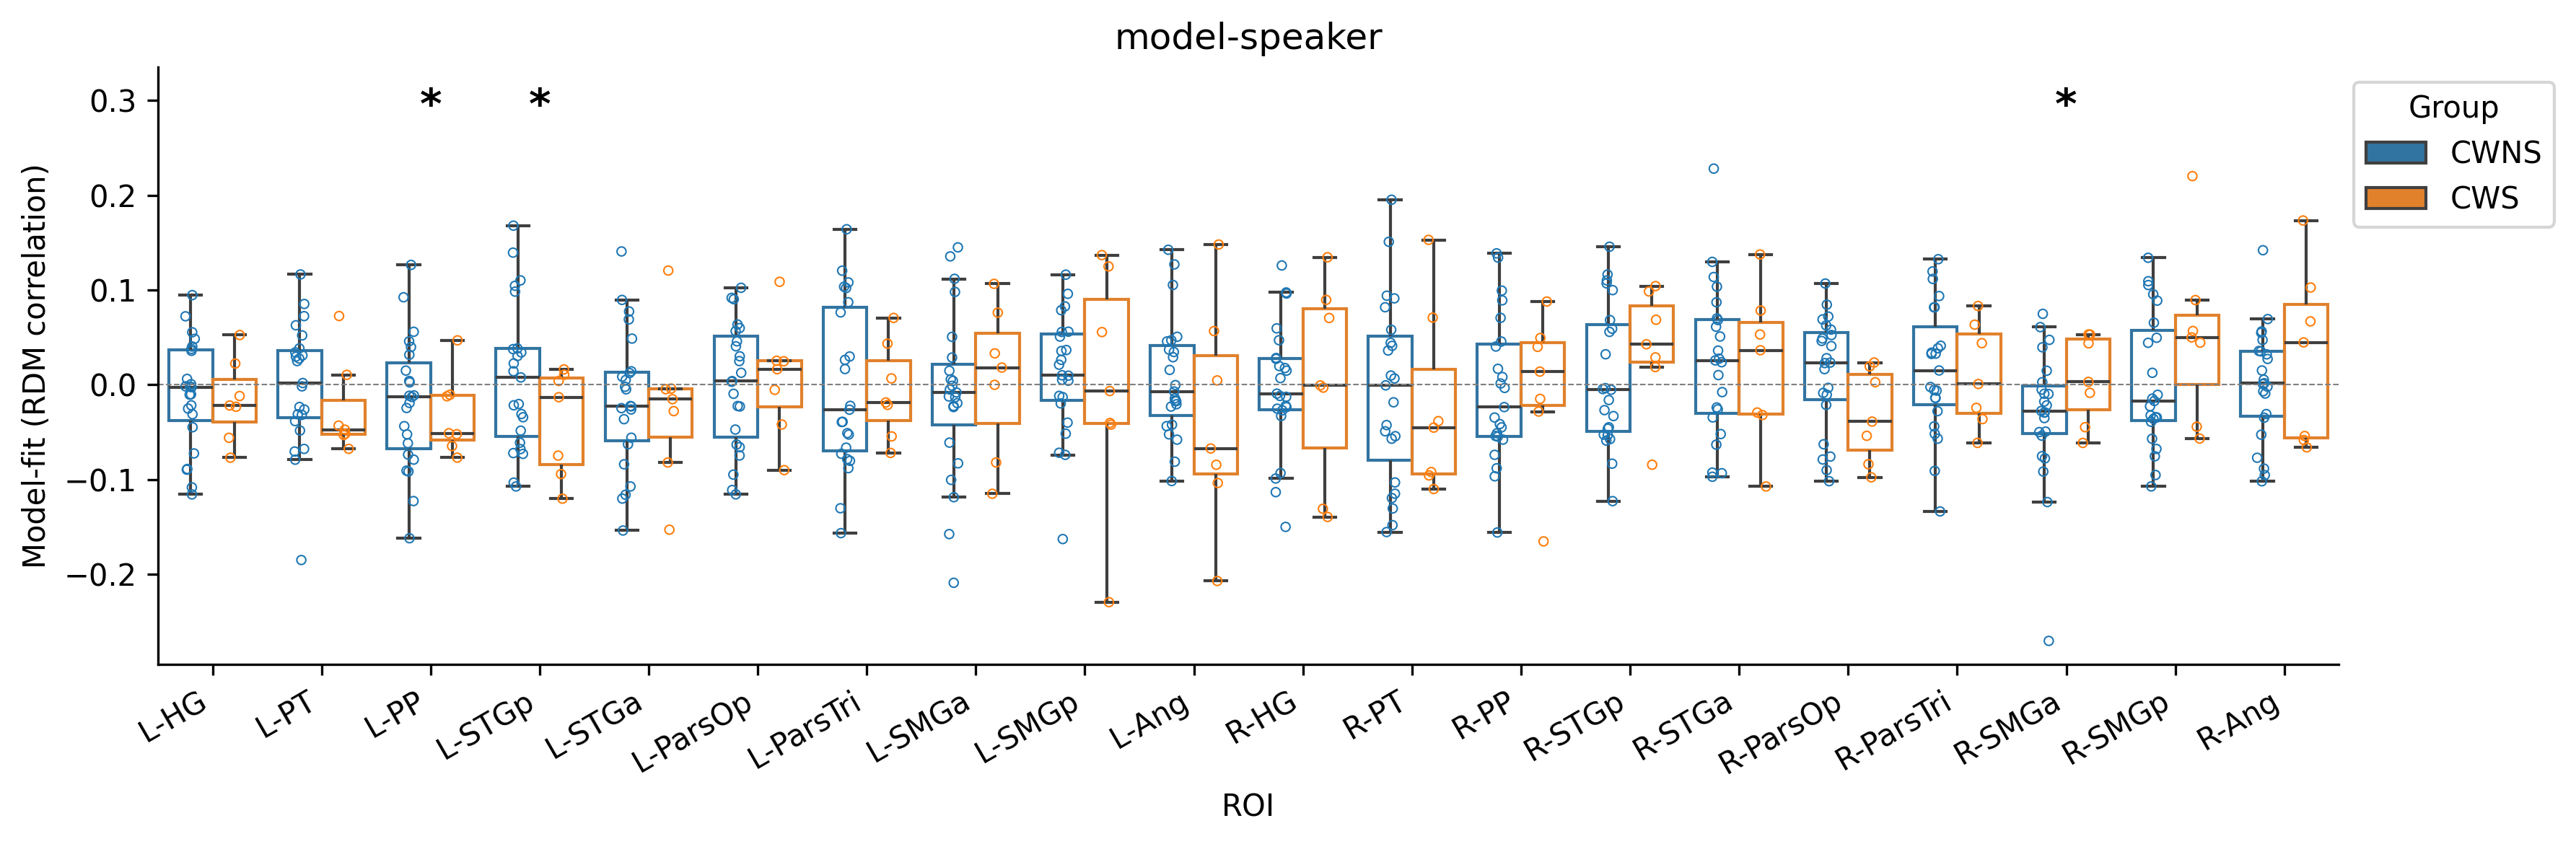

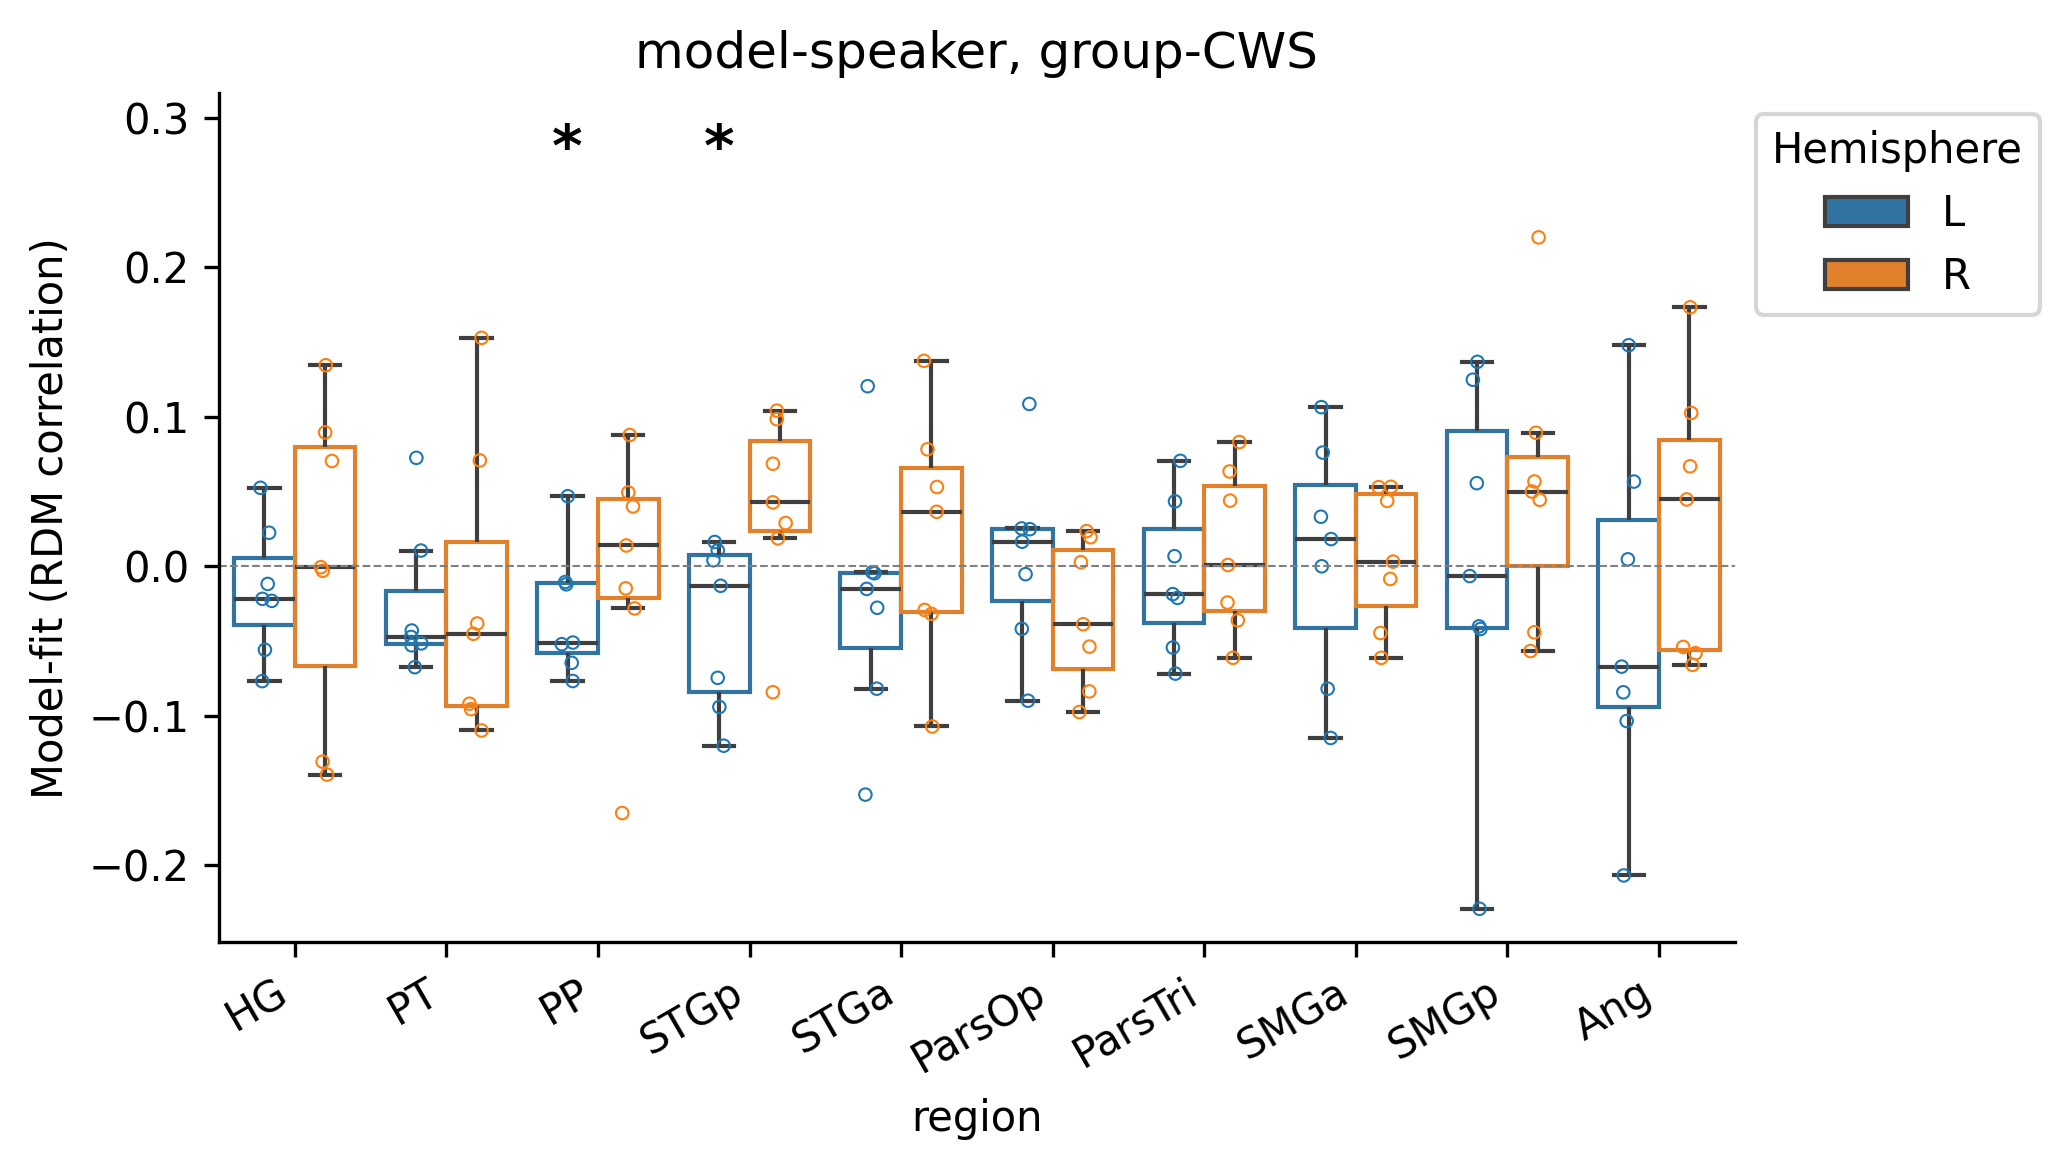

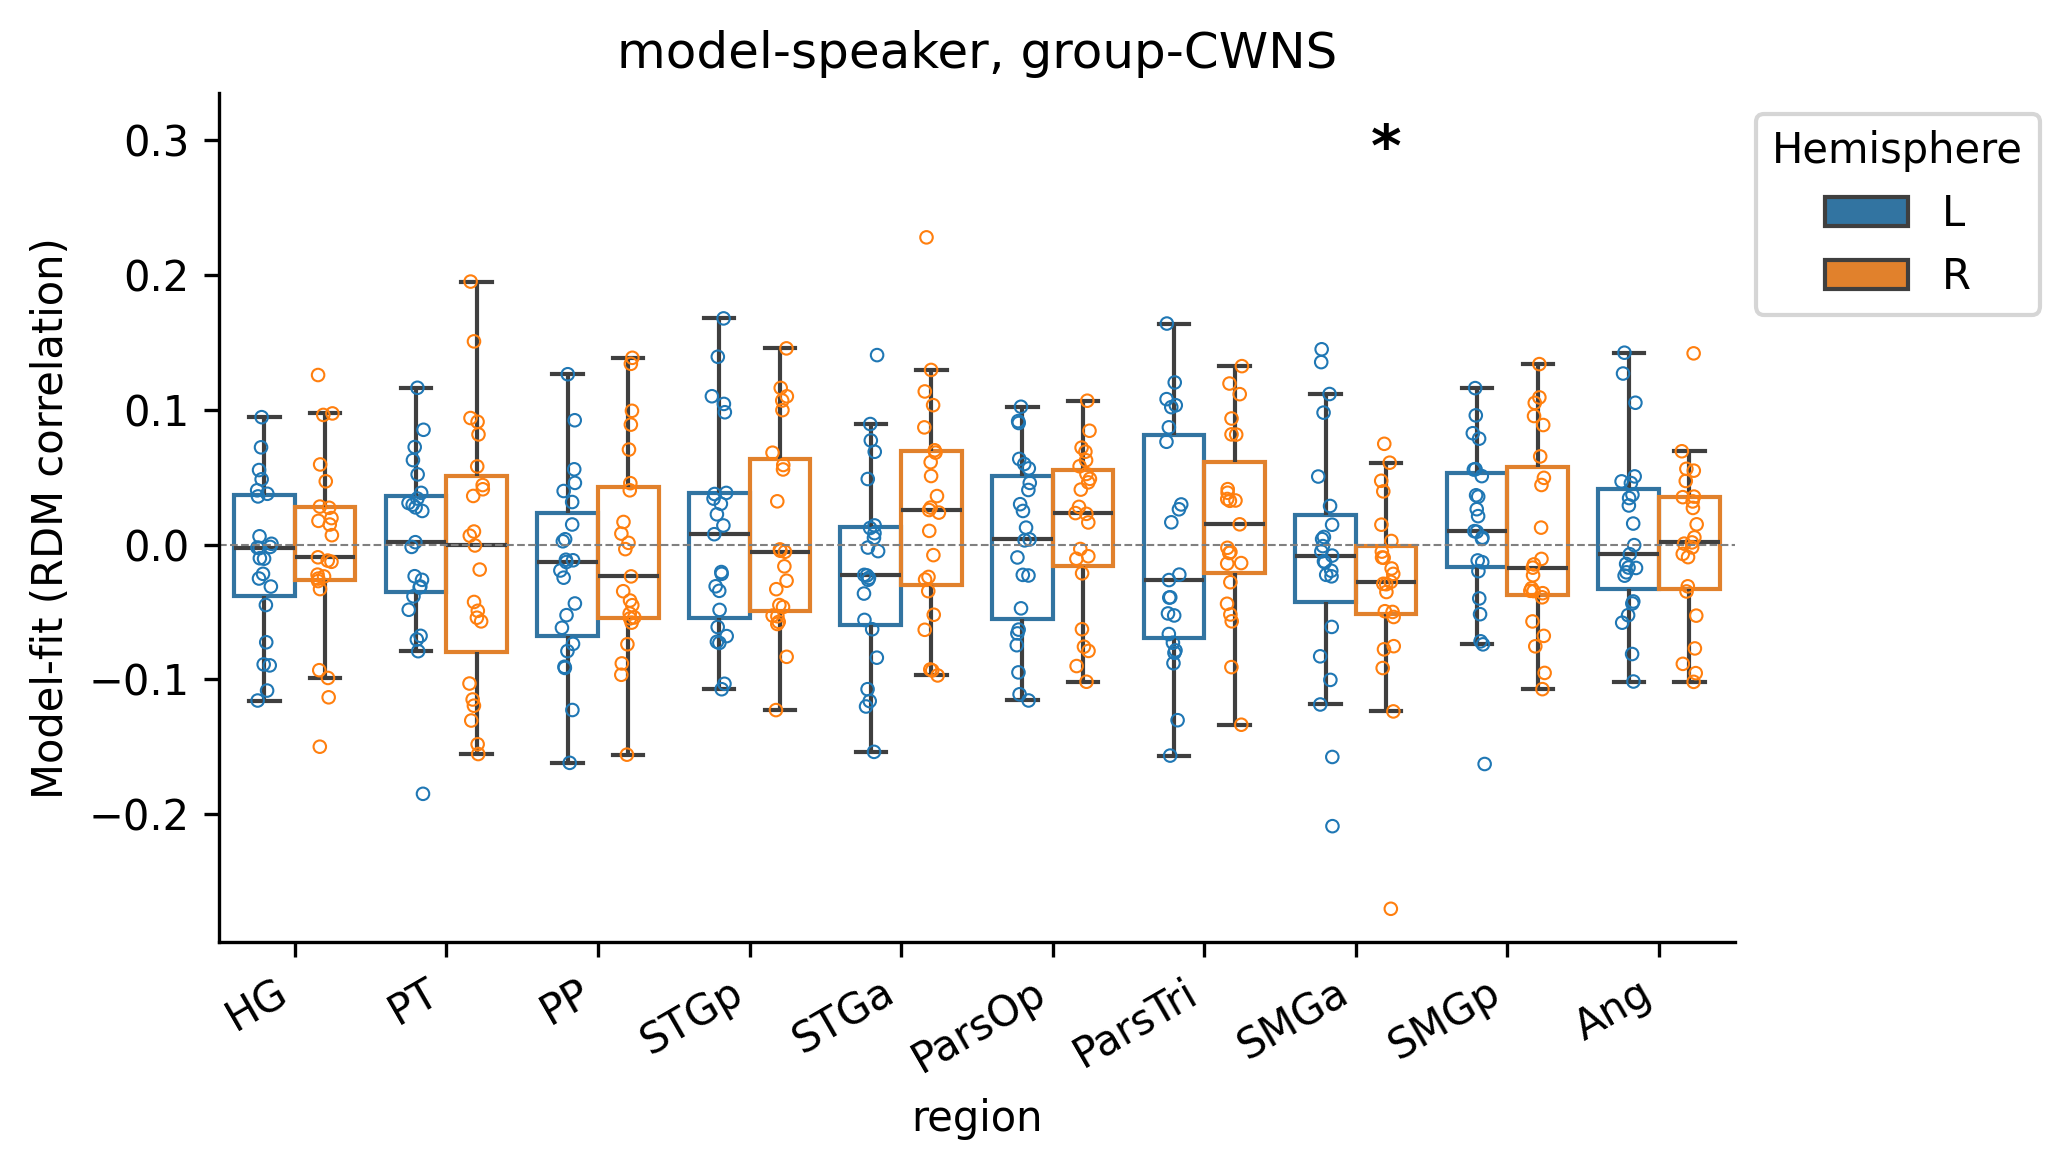

In [12]:
def _outline_only(ax):
    """Strip fill from stripplot dots and boxplot boxes, re-applying each hue group's original
    fill color as the outline/edge color first -- so the now-transparent shapes are still
    outlined in the color they're assigned, rather than whatever default edge color seaborn
    would otherwise leave them with.
    """
    for collection in ax.collections:
        facecolor = collection.get_facecolor()
        collection.set_edgecolor(facecolor)
        collection.set_facecolor('none')
    for patch in ax.patches:
        facecolor = patch.get_facecolor()
        patch.set_edgecolor(facecolor)
        patch.set_facecolor('none')


def _add_asterisk_headroom(ax, y_top):
    """Compute an asterisk y-position with headroom above the highest data point, and expand
    the axes' y-limit to guarantee that headroom doesn't get clipped or collide with the title.
    NOTE: previously this used `y_top * 1.05`, which pushes the asterisk *down* (not up) whenever
    y_top is negative or near zero -- a real bug for model-fit values that can be small/negative.
    Using a fixed fraction of the actual visible y-range instead is correct regardless of sign.
    """
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    asterisk_y = y_top + 0.08 * y_range
    ax.set_ylim(y_min, y_max + 0.15 * y_range)
    return asterisk_y


def plot_roi_box_strip(model_fit_df, within_group_significance_df, model_name, roi_order):
    model_df = model_fit_df[model_fit_df.model == model_name]

    fig, ax = plt.subplots(1, 1, figsize=(0.5 * len(roi_order) + 2, 4), dpi=300)

    sns.stripplot(data=model_df, x='ROI', y='fit', hue='group', order=roi_order,
                 dodge=True, linewidth=0.5, size=3, legend=None, ax=ax, zorder=2)
    sns.boxplot(data=model_df, x='ROI', y='fit', hue='group', order=roi_order,
               dodge=True, linewidth=1, fliersize=0, ax=ax, zorder=1)
    _outline_only(ax)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), title='Group')
    ax.axhline(y=0, color='0.5', linestyle='--', linewidth=0.5)
    ax.set_ylabel('Model-fit (RDM correlation)')
    ax.set_title(f'model-{model_name}')

    # mark ROIs with ANY significant within-group effect (either group) with an asterisk
    y_top = model_df['fit'].max()
    asterisk_y = _add_asterisk_headroom(ax, y_top)
    sig_rois = within_group_significance_df[
        (within_group_significance_df.model == model_name) &
        (within_group_significance_df.p_value < 0.05)
    ]['ROI'].unique()
    for roi in sig_rois:
        if roi in roi_order:
            ax.text(roi_order.index(roi), asterisk_y, '*', ha='center', va='bottom',
                    fontsize=14, fontweight='bold')

    fig.tight_layout()
    sns.despine(ax=ax)
    return fig


# Seaborn's default dodge for 2 hue categories with the default box width (0.8) centers each
# hue's sub-box at +/-0.2 from the category tick position. This is a best-effort approximation
# of seaborn's internal dodge math (no local seaborn install to verify exact positions against)
# -- check visually on first real render and adjust if asterisks don't land exactly over their
# boxes. hue_order is passed explicitly to both plot calls below so 'L' is always hue index 0
# (offset -0.2) and 'R' is always index 1 (offset +0.2), rather than relying on whatever order
# seaborn would otherwise infer from the data.
HEMISPHERE_ORDER = ['L', 'R']
HEMISPHERE_OFFSET = {'L': -0.2, 'R': 0.2}


def plot_roi_box_strip_by_hemisphere(model_fit_df, within_group_significance_df, model_name,
                                     group_name, region_order):
    """Group-specific variant: x=region (hemisphere prefix stripped), hue=hemisphere. Fewer
    x-categories than plot_roi_box_strip's combined (x=ROI, hue=group) view -- one figure per
    (model, group) instead of one per model. Asterisks are placed over the specific L or R box
    (not the region's center), so significance is shown per-hemisphere, not pooled across both.
    """
    group_df = model_fit_df[(model_fit_df.model == model_name) & (model_fit_df.group == group_name)].copy()
    group_df['hemisphere'] = group_df['ROI'].str.split('-', n=1).str[0]
    group_df['region'] = group_df['ROI'].str.split('-', n=1).str[1]

    fig, ax = plt.subplots(1, 1, figsize=(0.5 * len(region_order) + 2, 4), dpi=300)

    sns.stripplot(data=group_df, x='region', y='fit', hue='hemisphere', order=region_order,
                 hue_order=HEMISPHERE_ORDER,
                 dodge=True, linewidth=0.5, size=3, legend=None, ax=ax, zorder=2)
    sns.boxplot(data=group_df, x='region', y='fit', hue='hemisphere', order=region_order,
               hue_order=HEMISPHERE_ORDER,
               dodge=True, linewidth=1, fliersize=0, ax=ax, zorder=1)
    _outline_only(ax)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), title='Hemisphere')
    ax.axhline(y=0, color='0.5', linestyle='--', linewidth=0.5)
    ax.set_ylabel('Model-fit (RDM correlation)')
    ax.set_title(f'model-{model_name}, group-{group_name}')

    # mark the SPECIFIC L or R box with an asterisk, per-hemisphere, using the dodge offsets above
    y_top = group_df['fit'].max()
    asterisk_y = _add_asterisk_headroom(ax, y_top)
    sig_rois_set = set(within_group_significance_df[
        (within_group_significance_df.model == model_name) &
        (within_group_significance_df.group == group_name) &
        (within_group_significance_df.p_value < 0.05)
    ]['ROI'])
    for hemi, offset in HEMISPHERE_OFFSET.items():
        for region_idx, region in enumerate(region_order):
            if f'{hemi}-{region}' in sig_rois_set:
                ax.text(region_idx + offset, asterisk_y, '*', ha='center', va='bottom',
                        fontsize=14, fontweight='bold')

    fig.tight_layout()
    sns.despine(ax=ax)
    return fig


for model_name in categorical_model_rdms.keys():
    fig = plot_roi_box_strip(model_fit_df, within_group_significance_df, model_name, CORTICAL_ROI_LIST)
    fig.savefig(os.path.join(out_dir, f'boxplot_model-{model_name}_noiselevel-{NOISE_LEVEL_TAG}.png'))
    fig.savefig(os.path.join(out_dir, f'boxplot_model-{model_name}_noiselevel-{NOISE_LEVEL_TAG}.svg'))

    for group_name in ['CWS', 'CWNS']:
        fig = plot_roi_box_strip_by_hemisphere(model_fit_df, within_group_significance_df,
                                               model_name, group_name, BASE_REGION_ORDER)
        fig.savefig(os.path.join(
            out_dir, f'boxplot_model-{model_name}_group-{group_name}_by-hemisphere_noiselevel-{NOISE_LEVEL_TAG}.png'))
        fig.savefig(os.path.join(
            out_dir, f'boxplot_model-{model_name}_group-{group_name}_by-hemisphere_noiselevel-{NOISE_LEVEL_TAG}.svg'))

### Brain plots (surface-based)

Reuses `roi_surface_plotting.py` (copied from `fMRI_auditory-category-learning/`, unmodified)
to project per-ROI scalars onto the fsaverage surface. For each model, three panels matching
the CWNS/CWS/diff convention already used throughout this pipeline: CWS-mean model-fit,
CWNS-mean model-fit (both from the within-group significance test above), and the CWS-CWNS
bootstrap `observed_diff` (from the between-group comparison above).

In [13]:
from roi_surface_plotting import plot_roi_surface_stat, build_mask_path_dict

masks_dir = os.path.join(bidsroot, 'derivatives', 'nilearn', 'masks')
space_label = 'MNI152NLin2009cAsym'

# network_name='dseg' passed directly (the actual mask-directory atlas name), rather than adding
# a new 'cortical' branch to build_mask_path_dict's network_name->mask_network_name mapping --
# avoids touching the copied reference module at all.
mask_path_dict = build_mask_path_dict(CORTICAL_ROI_LIST, masks_dir, network_name='dseg', space_label=space_label)

In [14]:
# Precompute the per-model stat dicts once (fast -- no plotting yet). Splitting the actual
# plotting (slow: surface.vol_to_surf projects every vertex on the whole hemisphere surface,
# per ROI, per call) into separate cells below by comparison type (cws/cwns/diff) gives natural
# checkpoints -- if interrupted partway through, whichever cells already ran have their plots
# saved, and it's clear which comparison type is left to (re-)run.
stat_dicts_by_model = {}
for model_name in categorical_model_rdms.keys():
    cws_stat_dict = within_group_significance_df[
        (within_group_significance_df.model == model_name) &
        (within_group_significance_df.group == 'CWS')
    ].set_index('ROI')['observed_mean'].to_dict()
    cwns_stat_dict = within_group_significance_df[
        (within_group_significance_df.model == model_name) &
        (within_group_significance_df.group == 'CWNS')
    ].set_index('ROI')['observed_mean'].to_dict()
    diff_stat_dict = group_comparison_df[
        group_comparison_df.model == model_name
    ].set_index('ROI')['observed_diff'].to_dict()

    stat_dicts_by_model[model_name] = {'cws': cws_stat_dict, 'cwns': cwns_stat_dict, 'diff': diff_stat_dict}

print('models ready to plot:', list(stat_dicts_by_model.keys()))

models ready to plot: ['syllable', 'speaker']


In [15]:
def plot_and_save_surface(model_name, label, stat_dict):
    if len(stat_dict) == 0:
        print(f'No data for model-{model_name}, group-{label} -- skipping brain plot.')
        return
    fig = plot_roi_surface_stat(
        stat_dict, mask_path_dict,
        title=f'model-{model_name}, group-{label} (noiselevel-{NOISE_LEVEL_TAG})',
    )
    fig.savefig(os.path.join(
        out_dir, f'surface_model-{model_name}_group-{label}_noiselevel-{NOISE_LEVEL_TAG}.png'))
    fig.savefig(os.path.join(
        out_dir, f'surface_model-{model_name}_group-{label}_noiselevel-{NOISE_LEVEL_TAG}.svg'))

#### CWS surface plots

[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


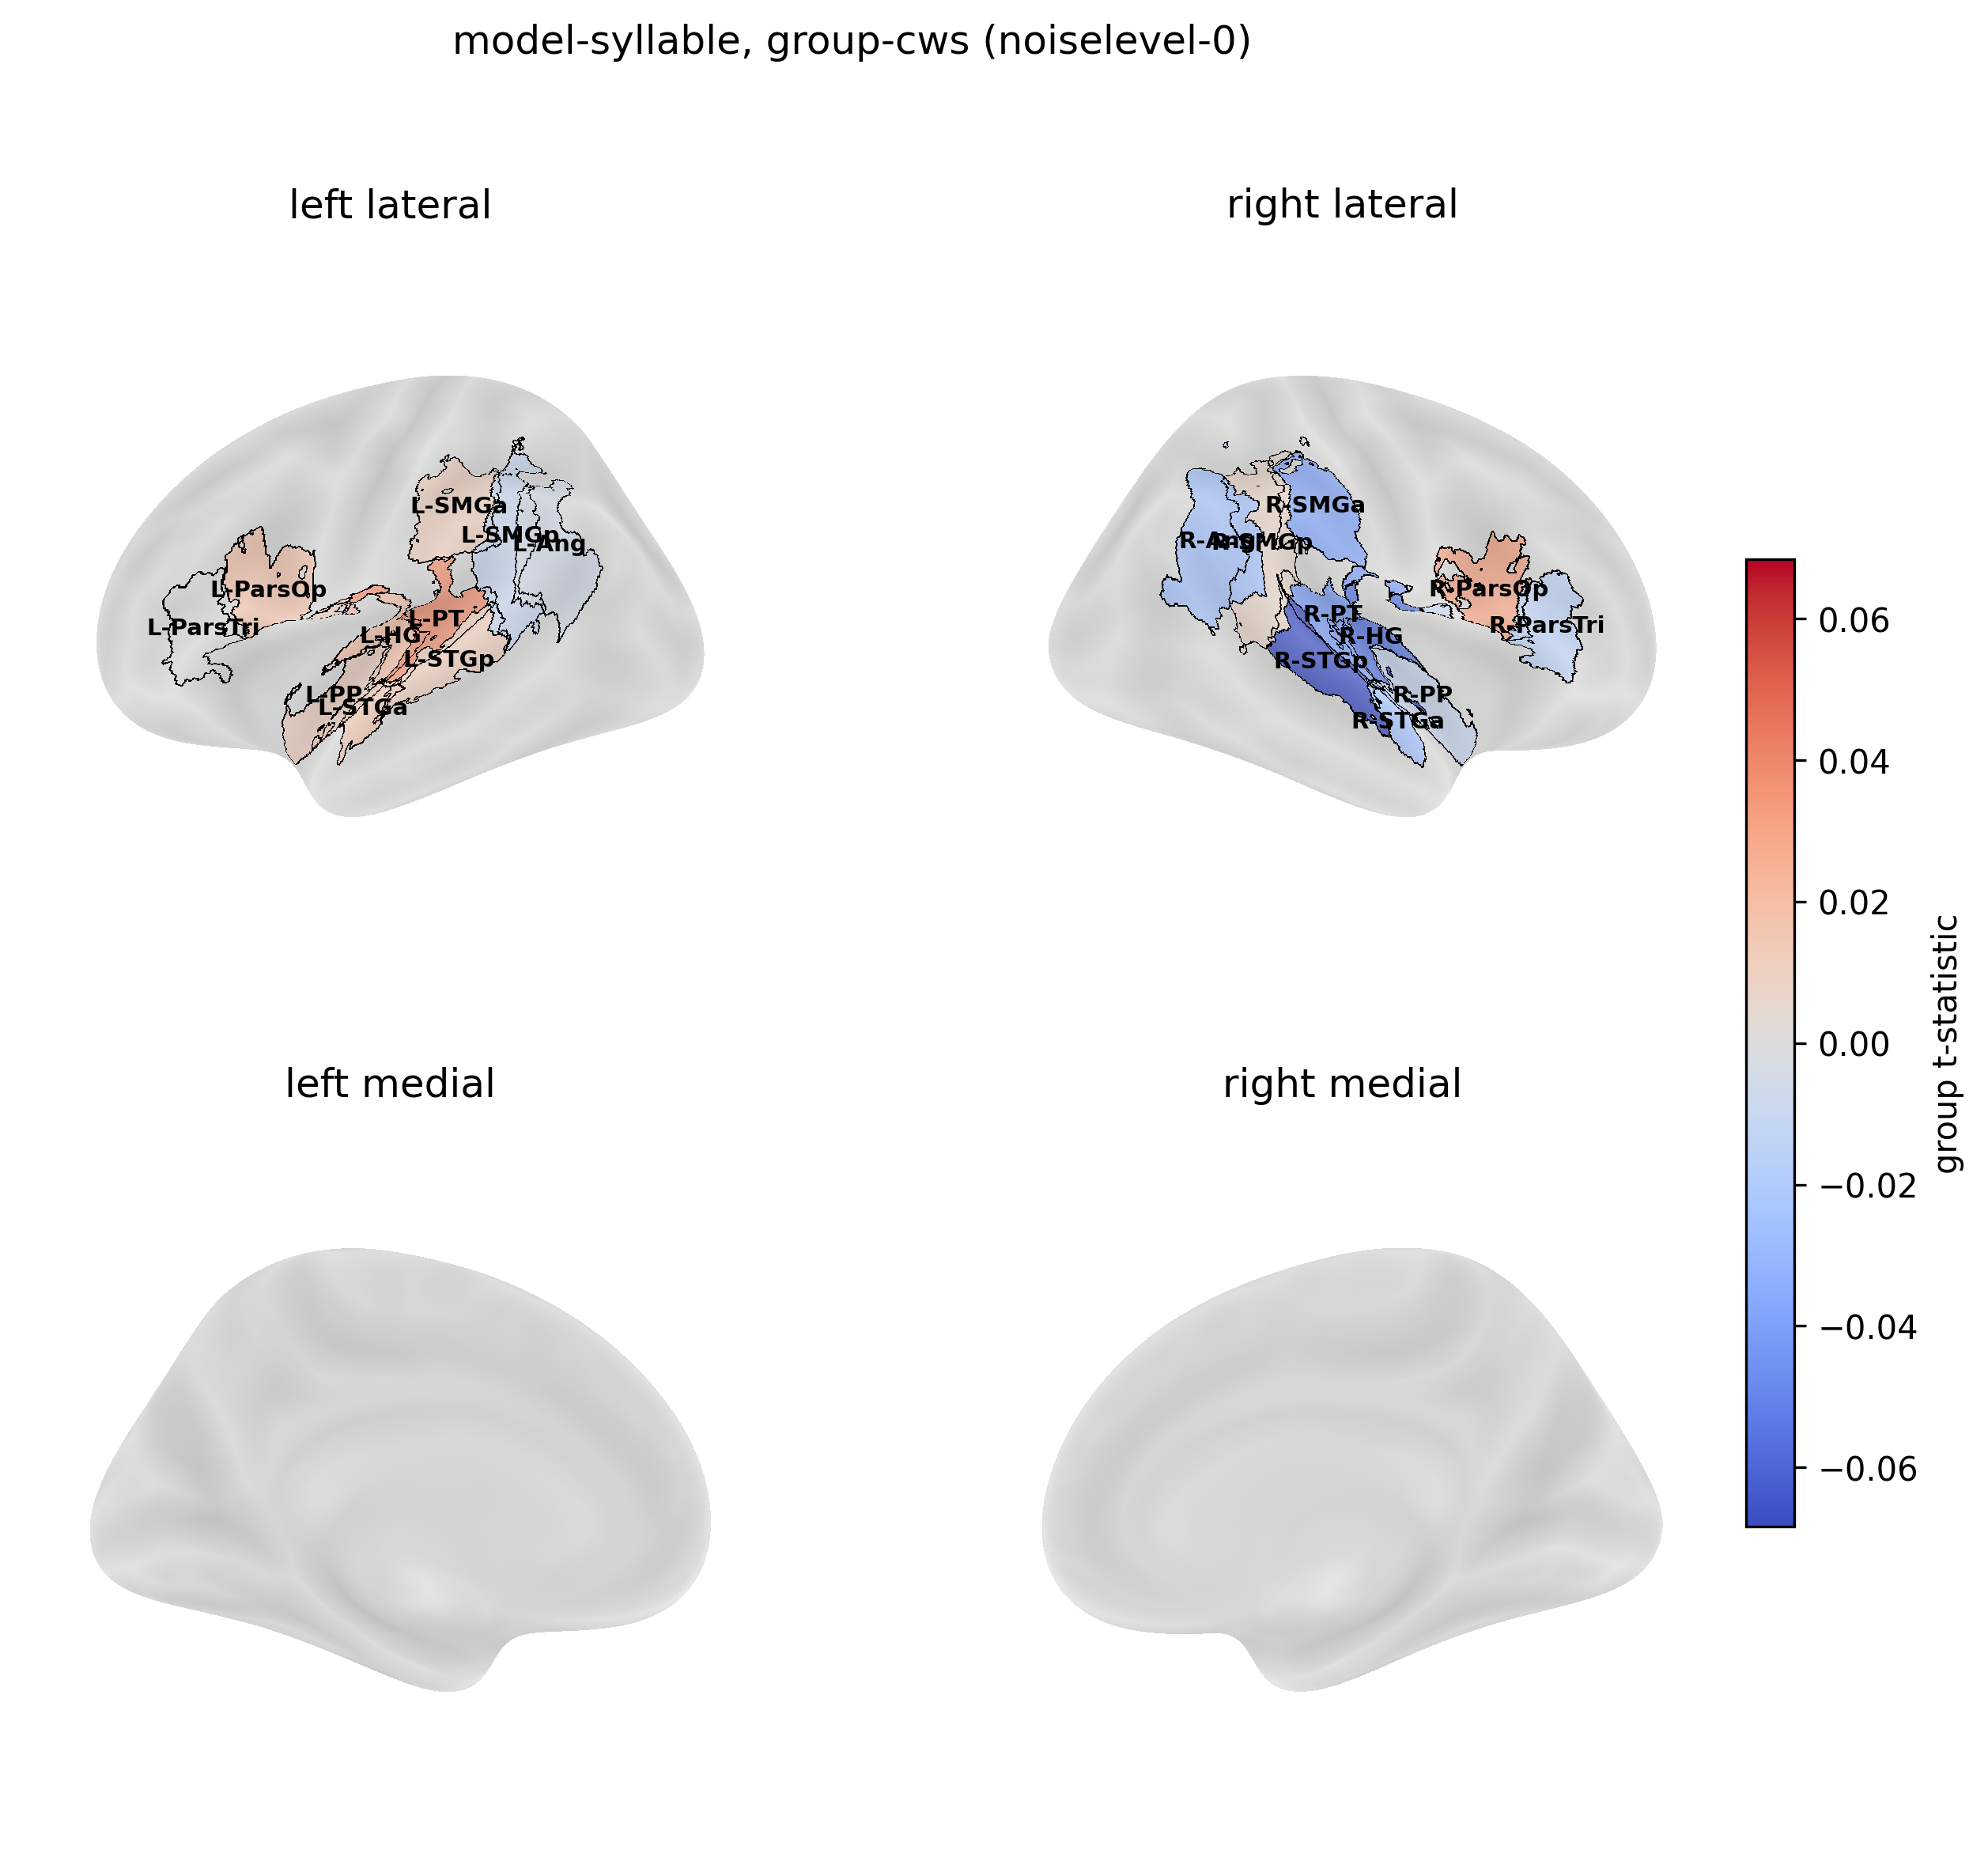

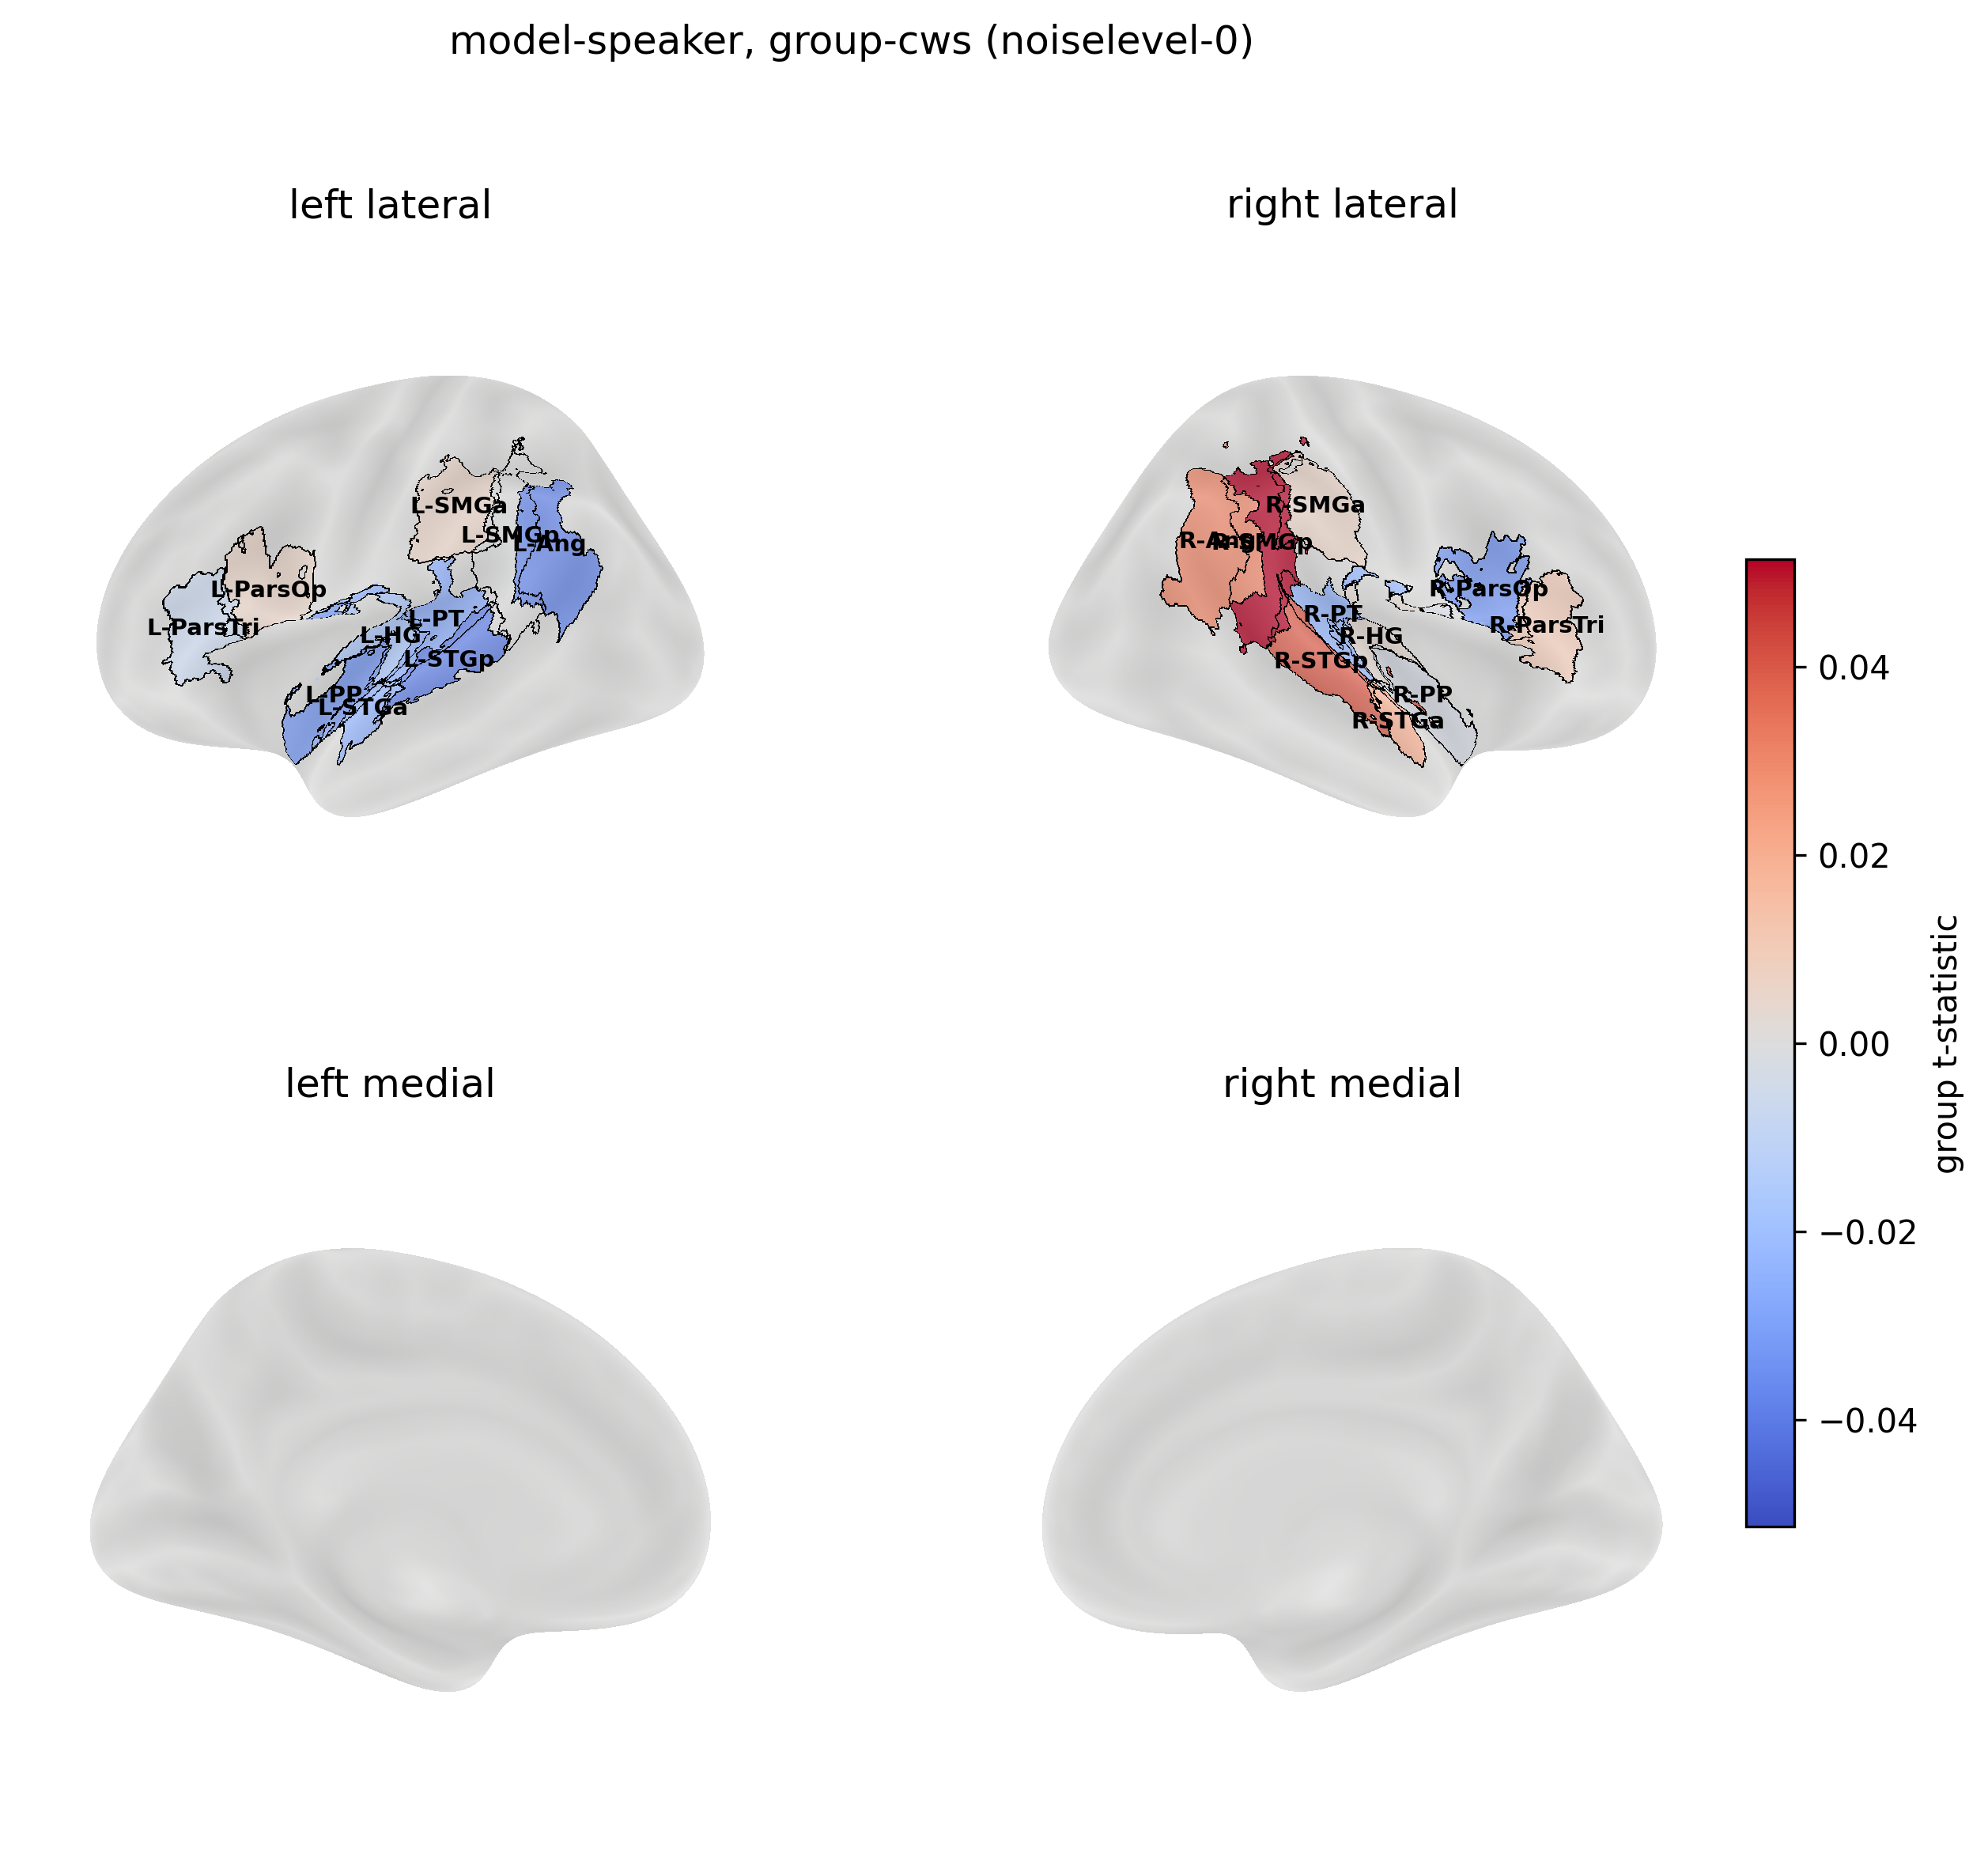

In [16]:
for model_name, stat_dicts in stat_dicts_by_model.items():
    plot_and_save_surface(model_name, 'cws', stat_dicts['cws'])

#### CWNS surface plots

[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


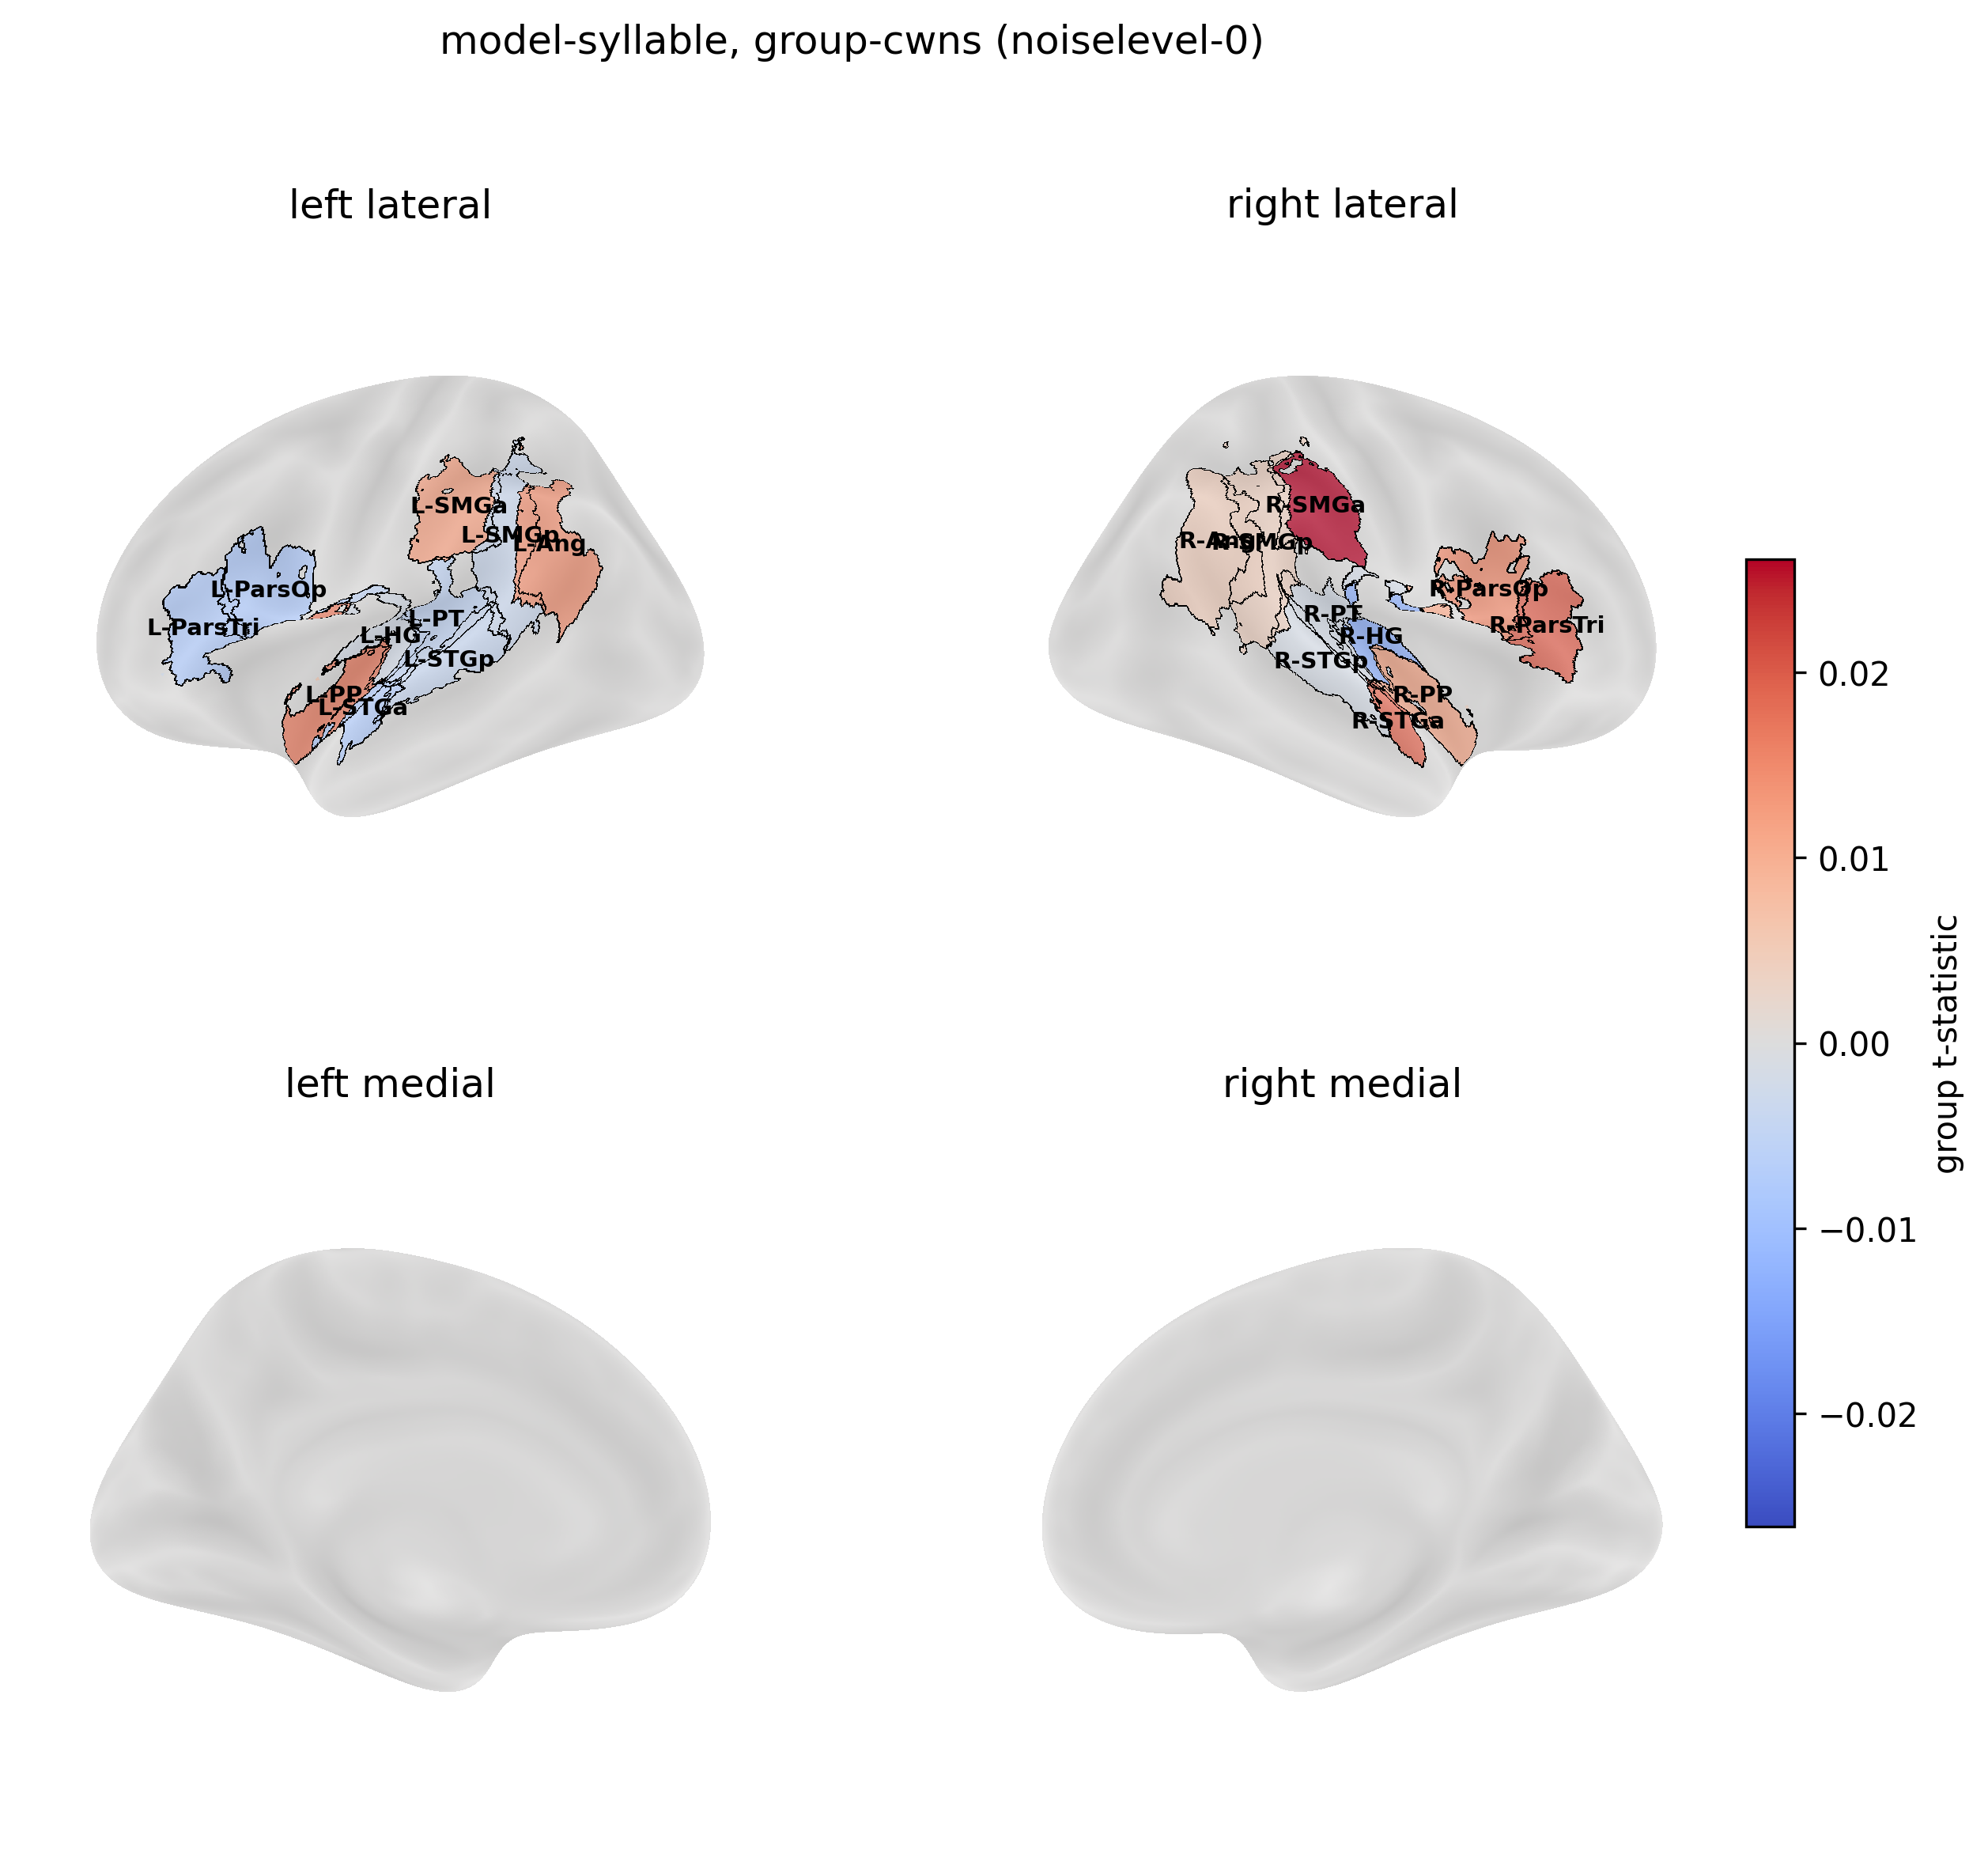

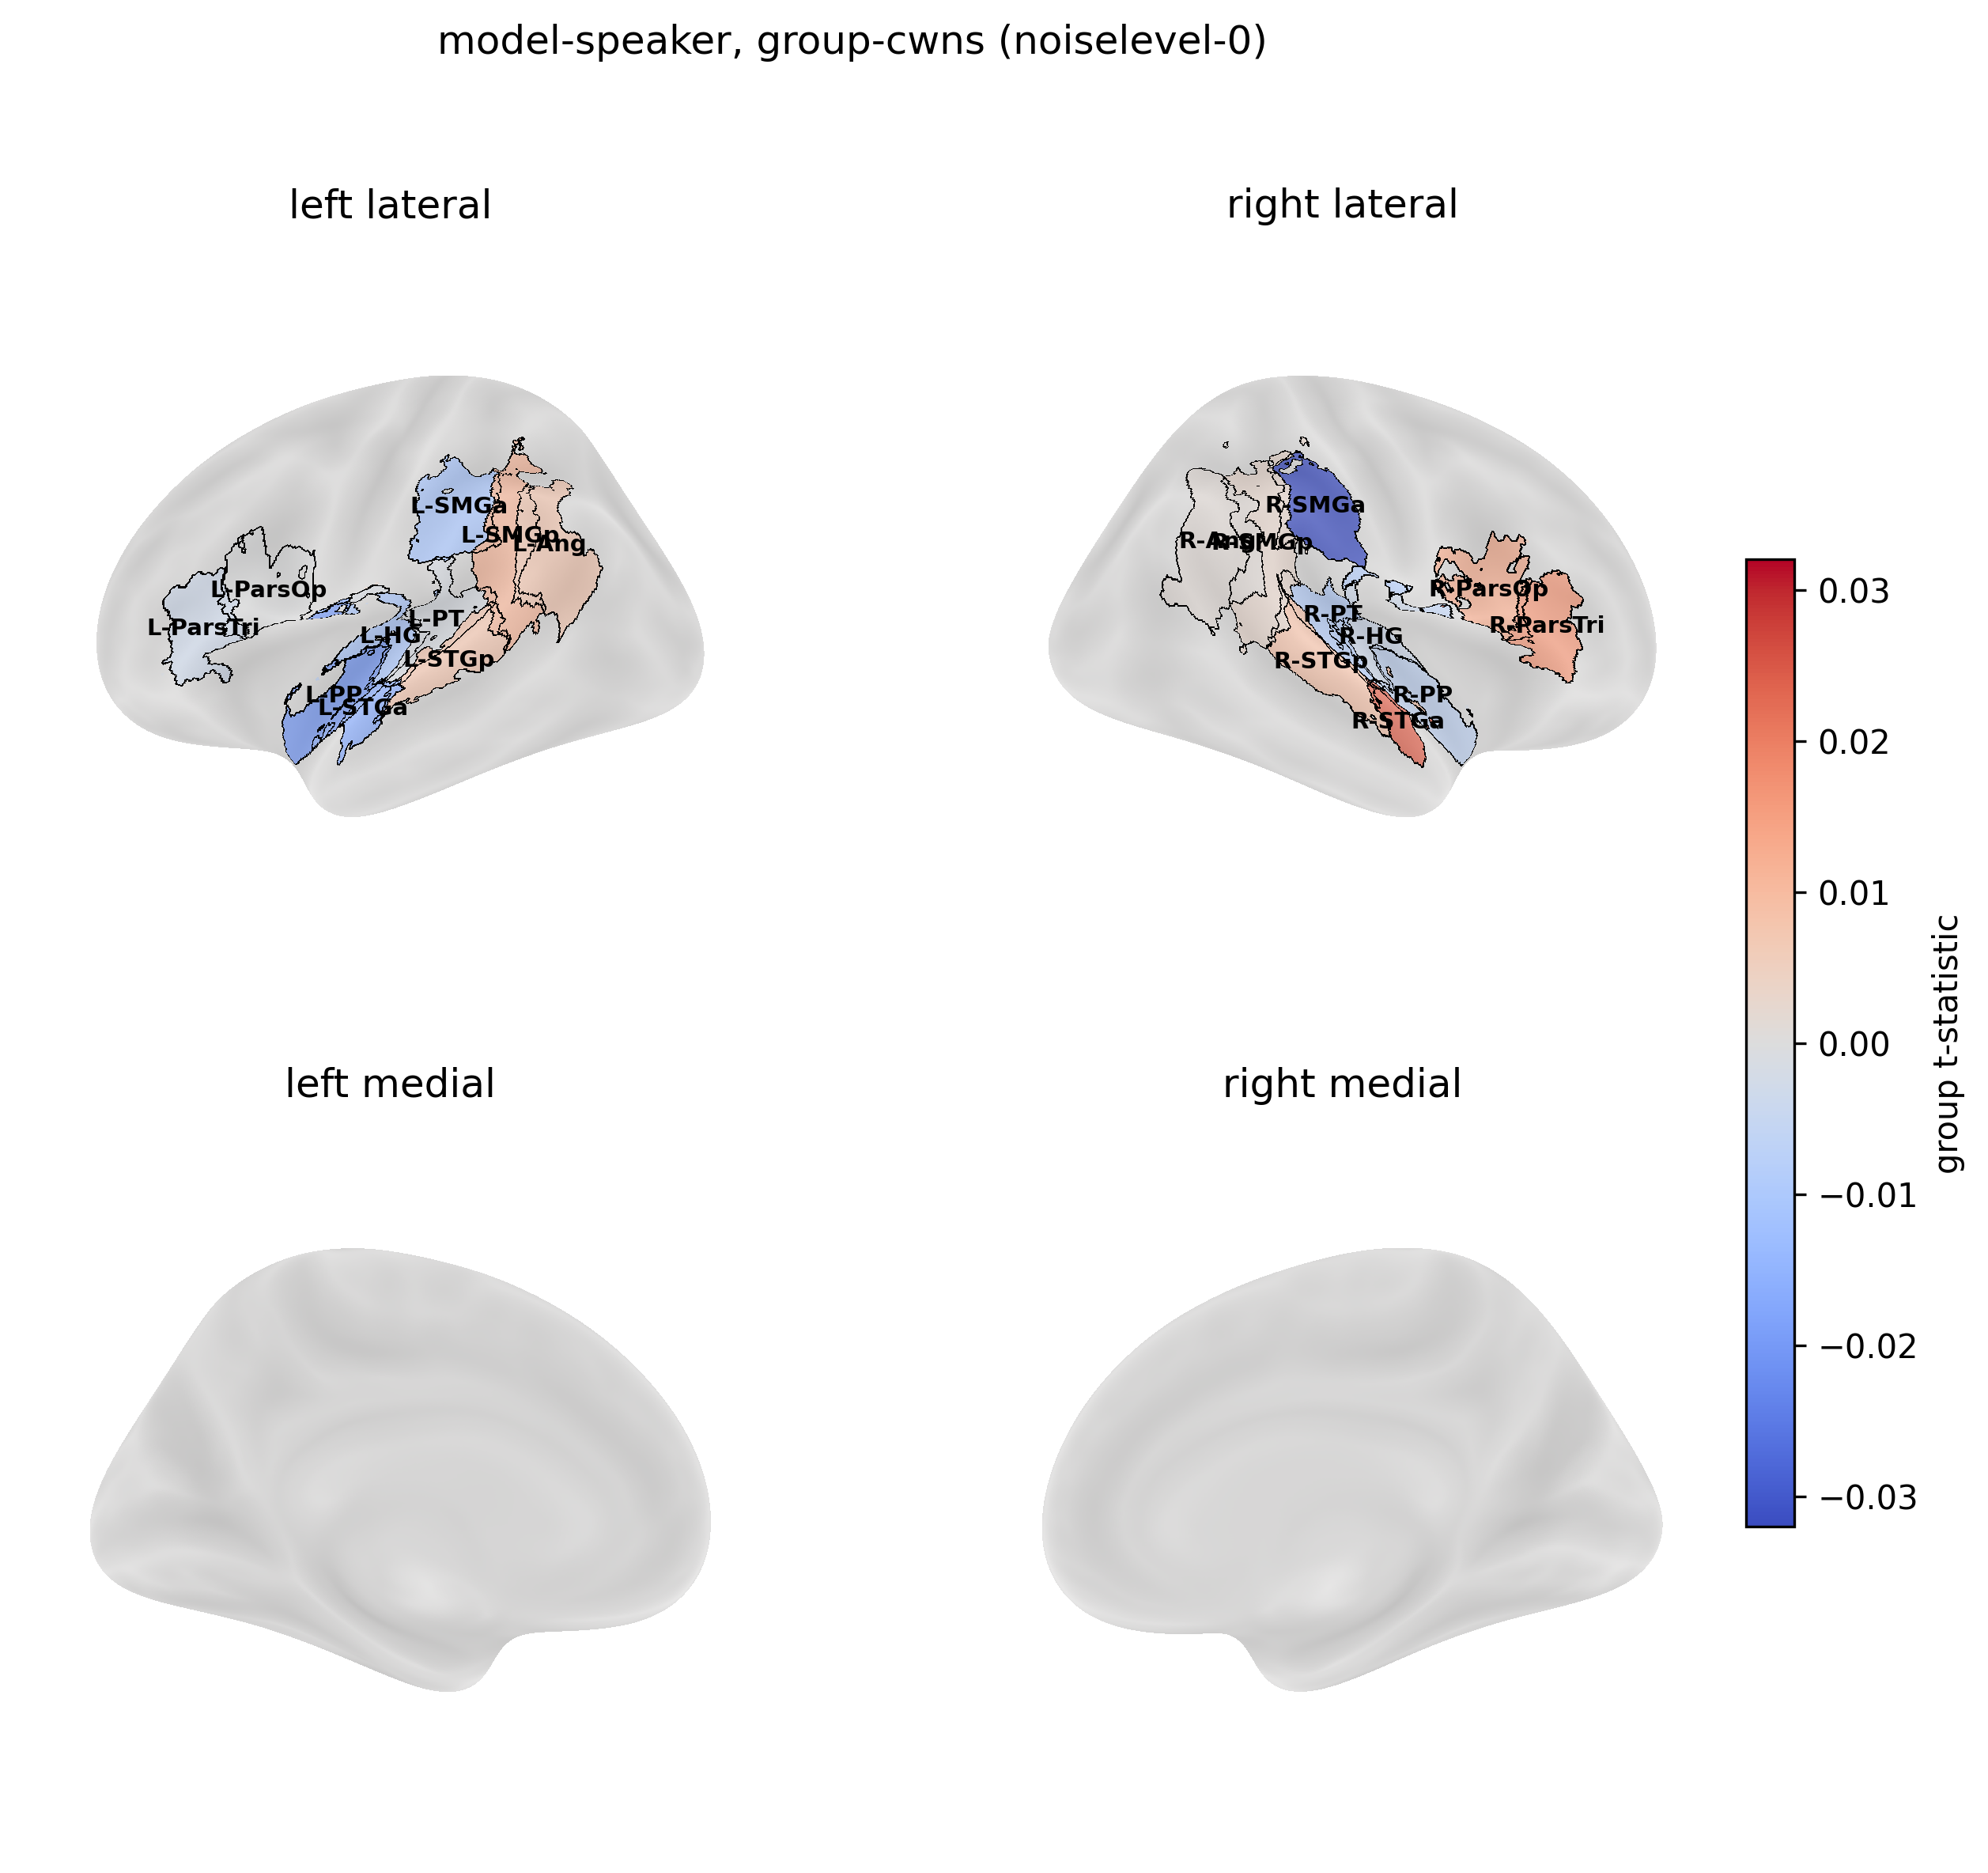

In [17]:
for model_name, stat_dicts in stat_dicts_by_model.items():
    plot_and_save_surface(model_name, 'cwns', stat_dicts['cwns'])

#### CWS − CWNS difference surface plots

[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage
[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


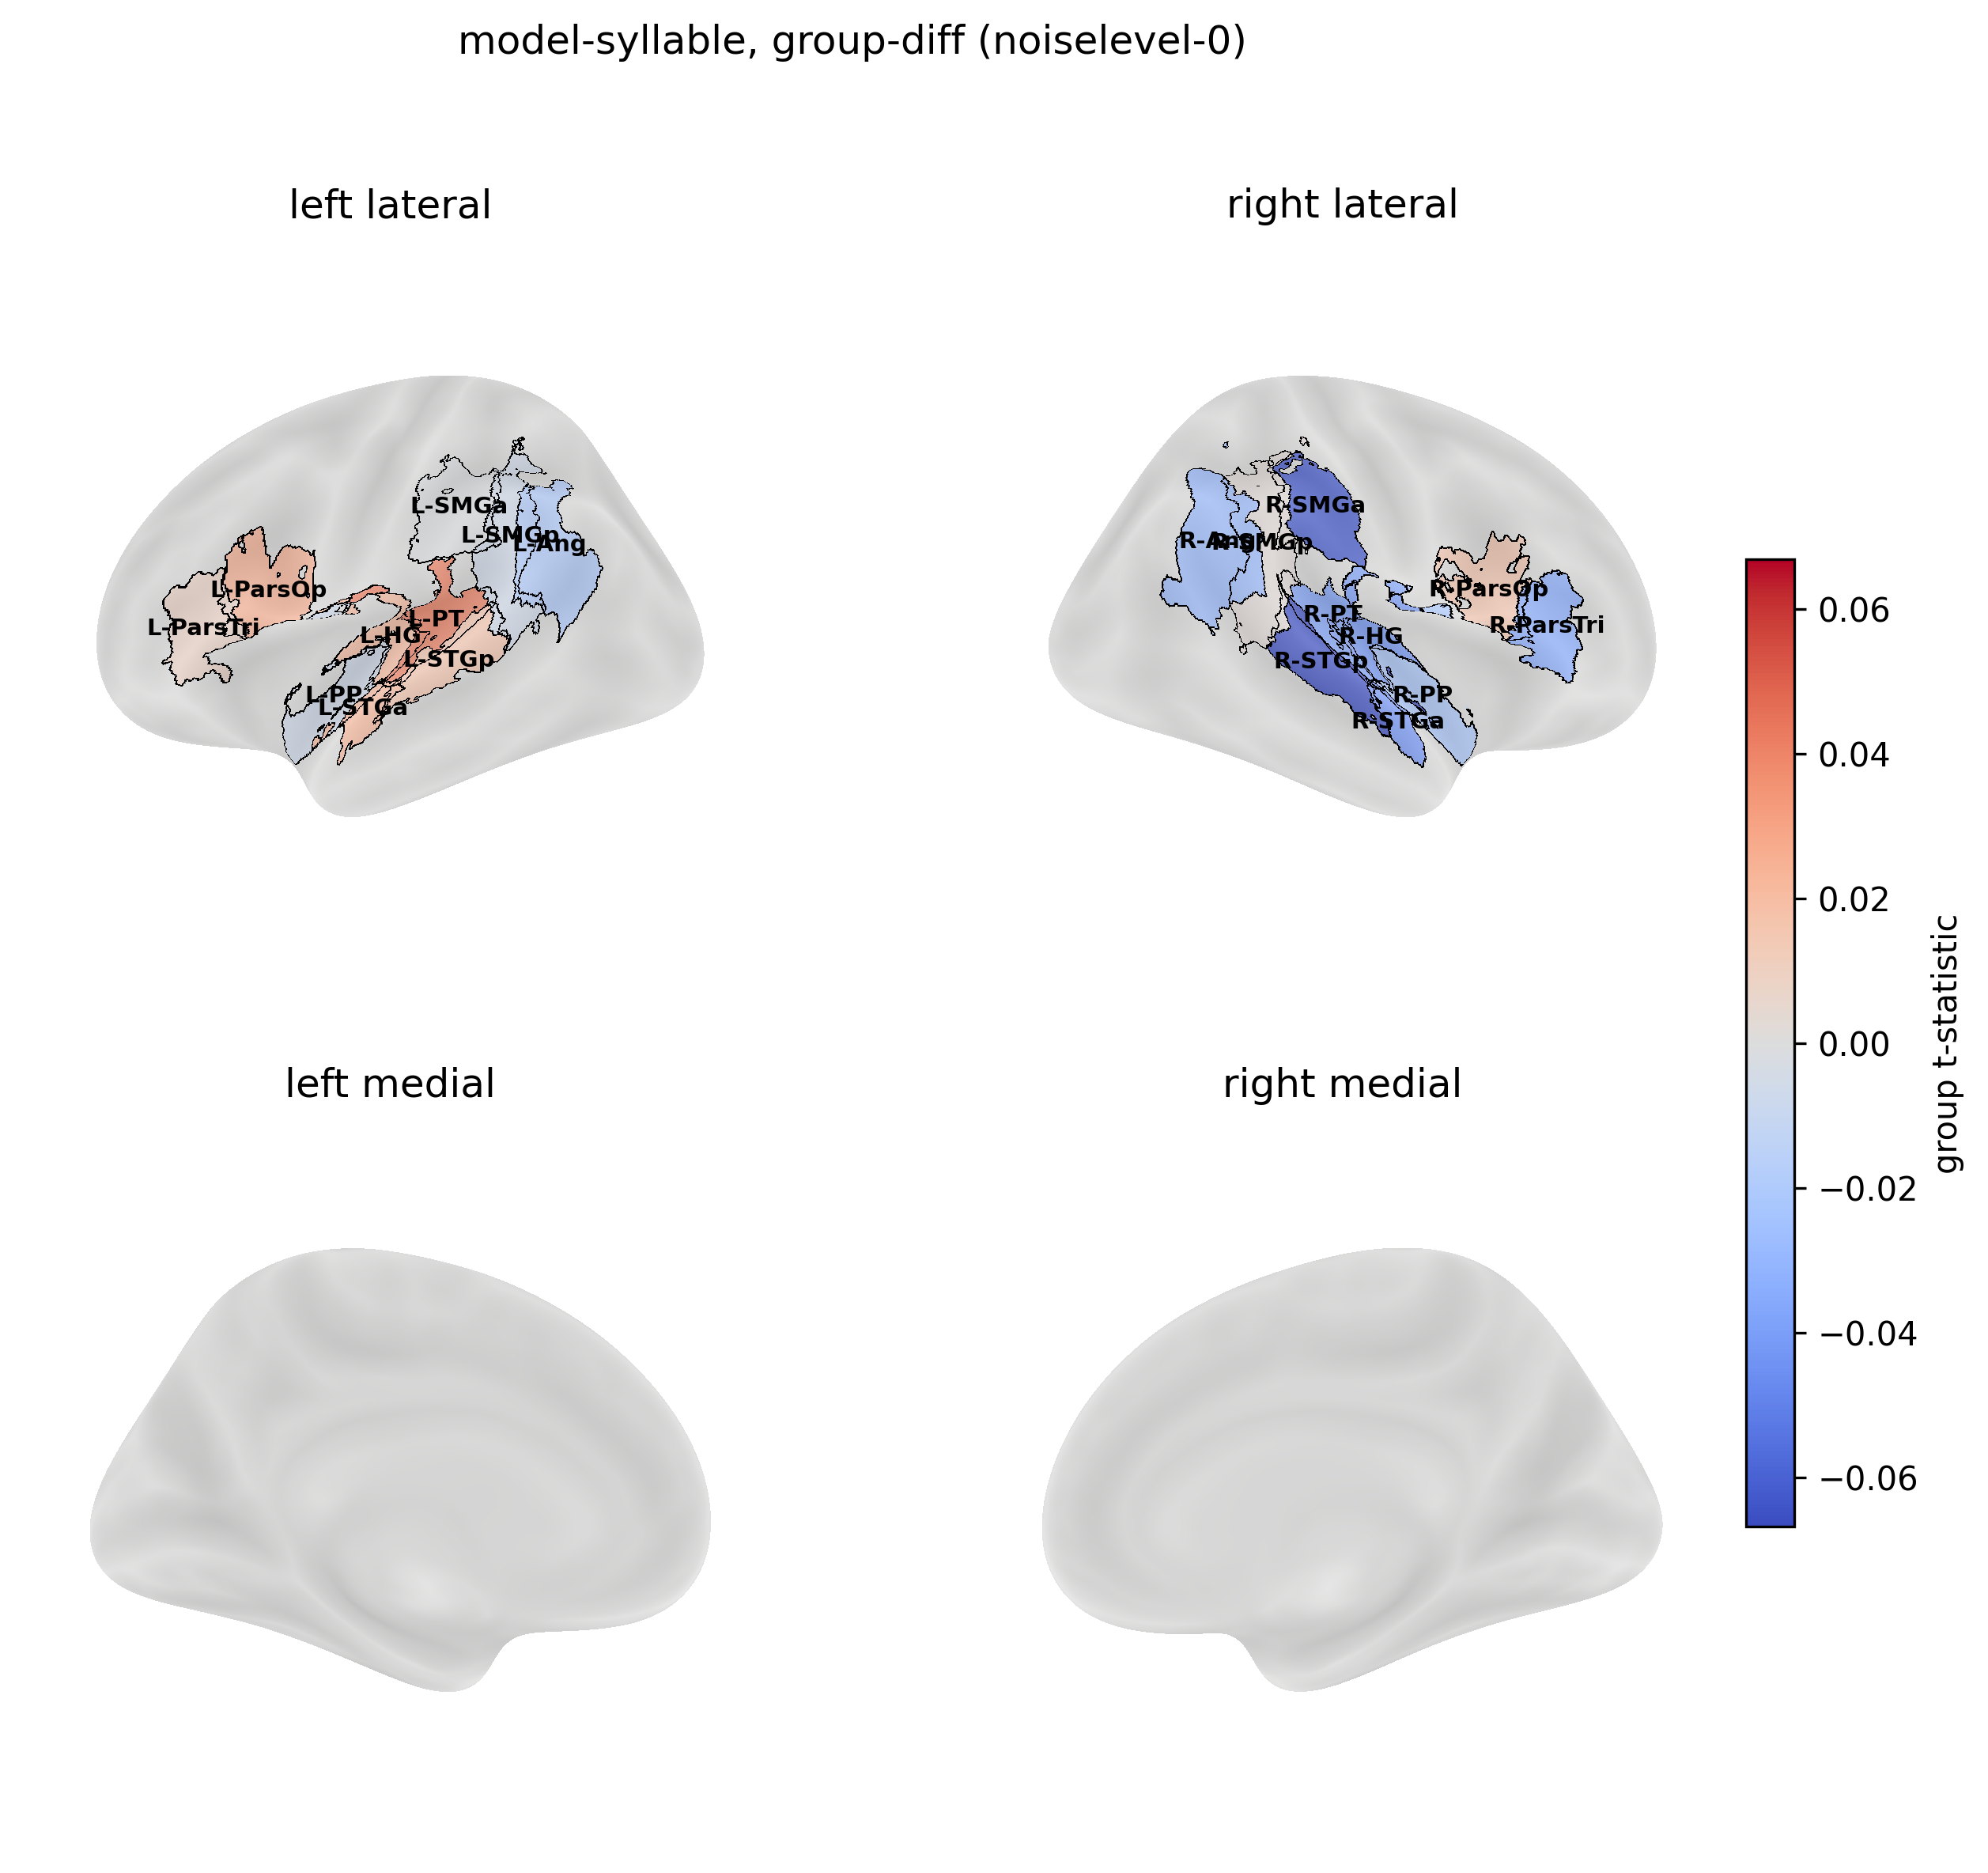

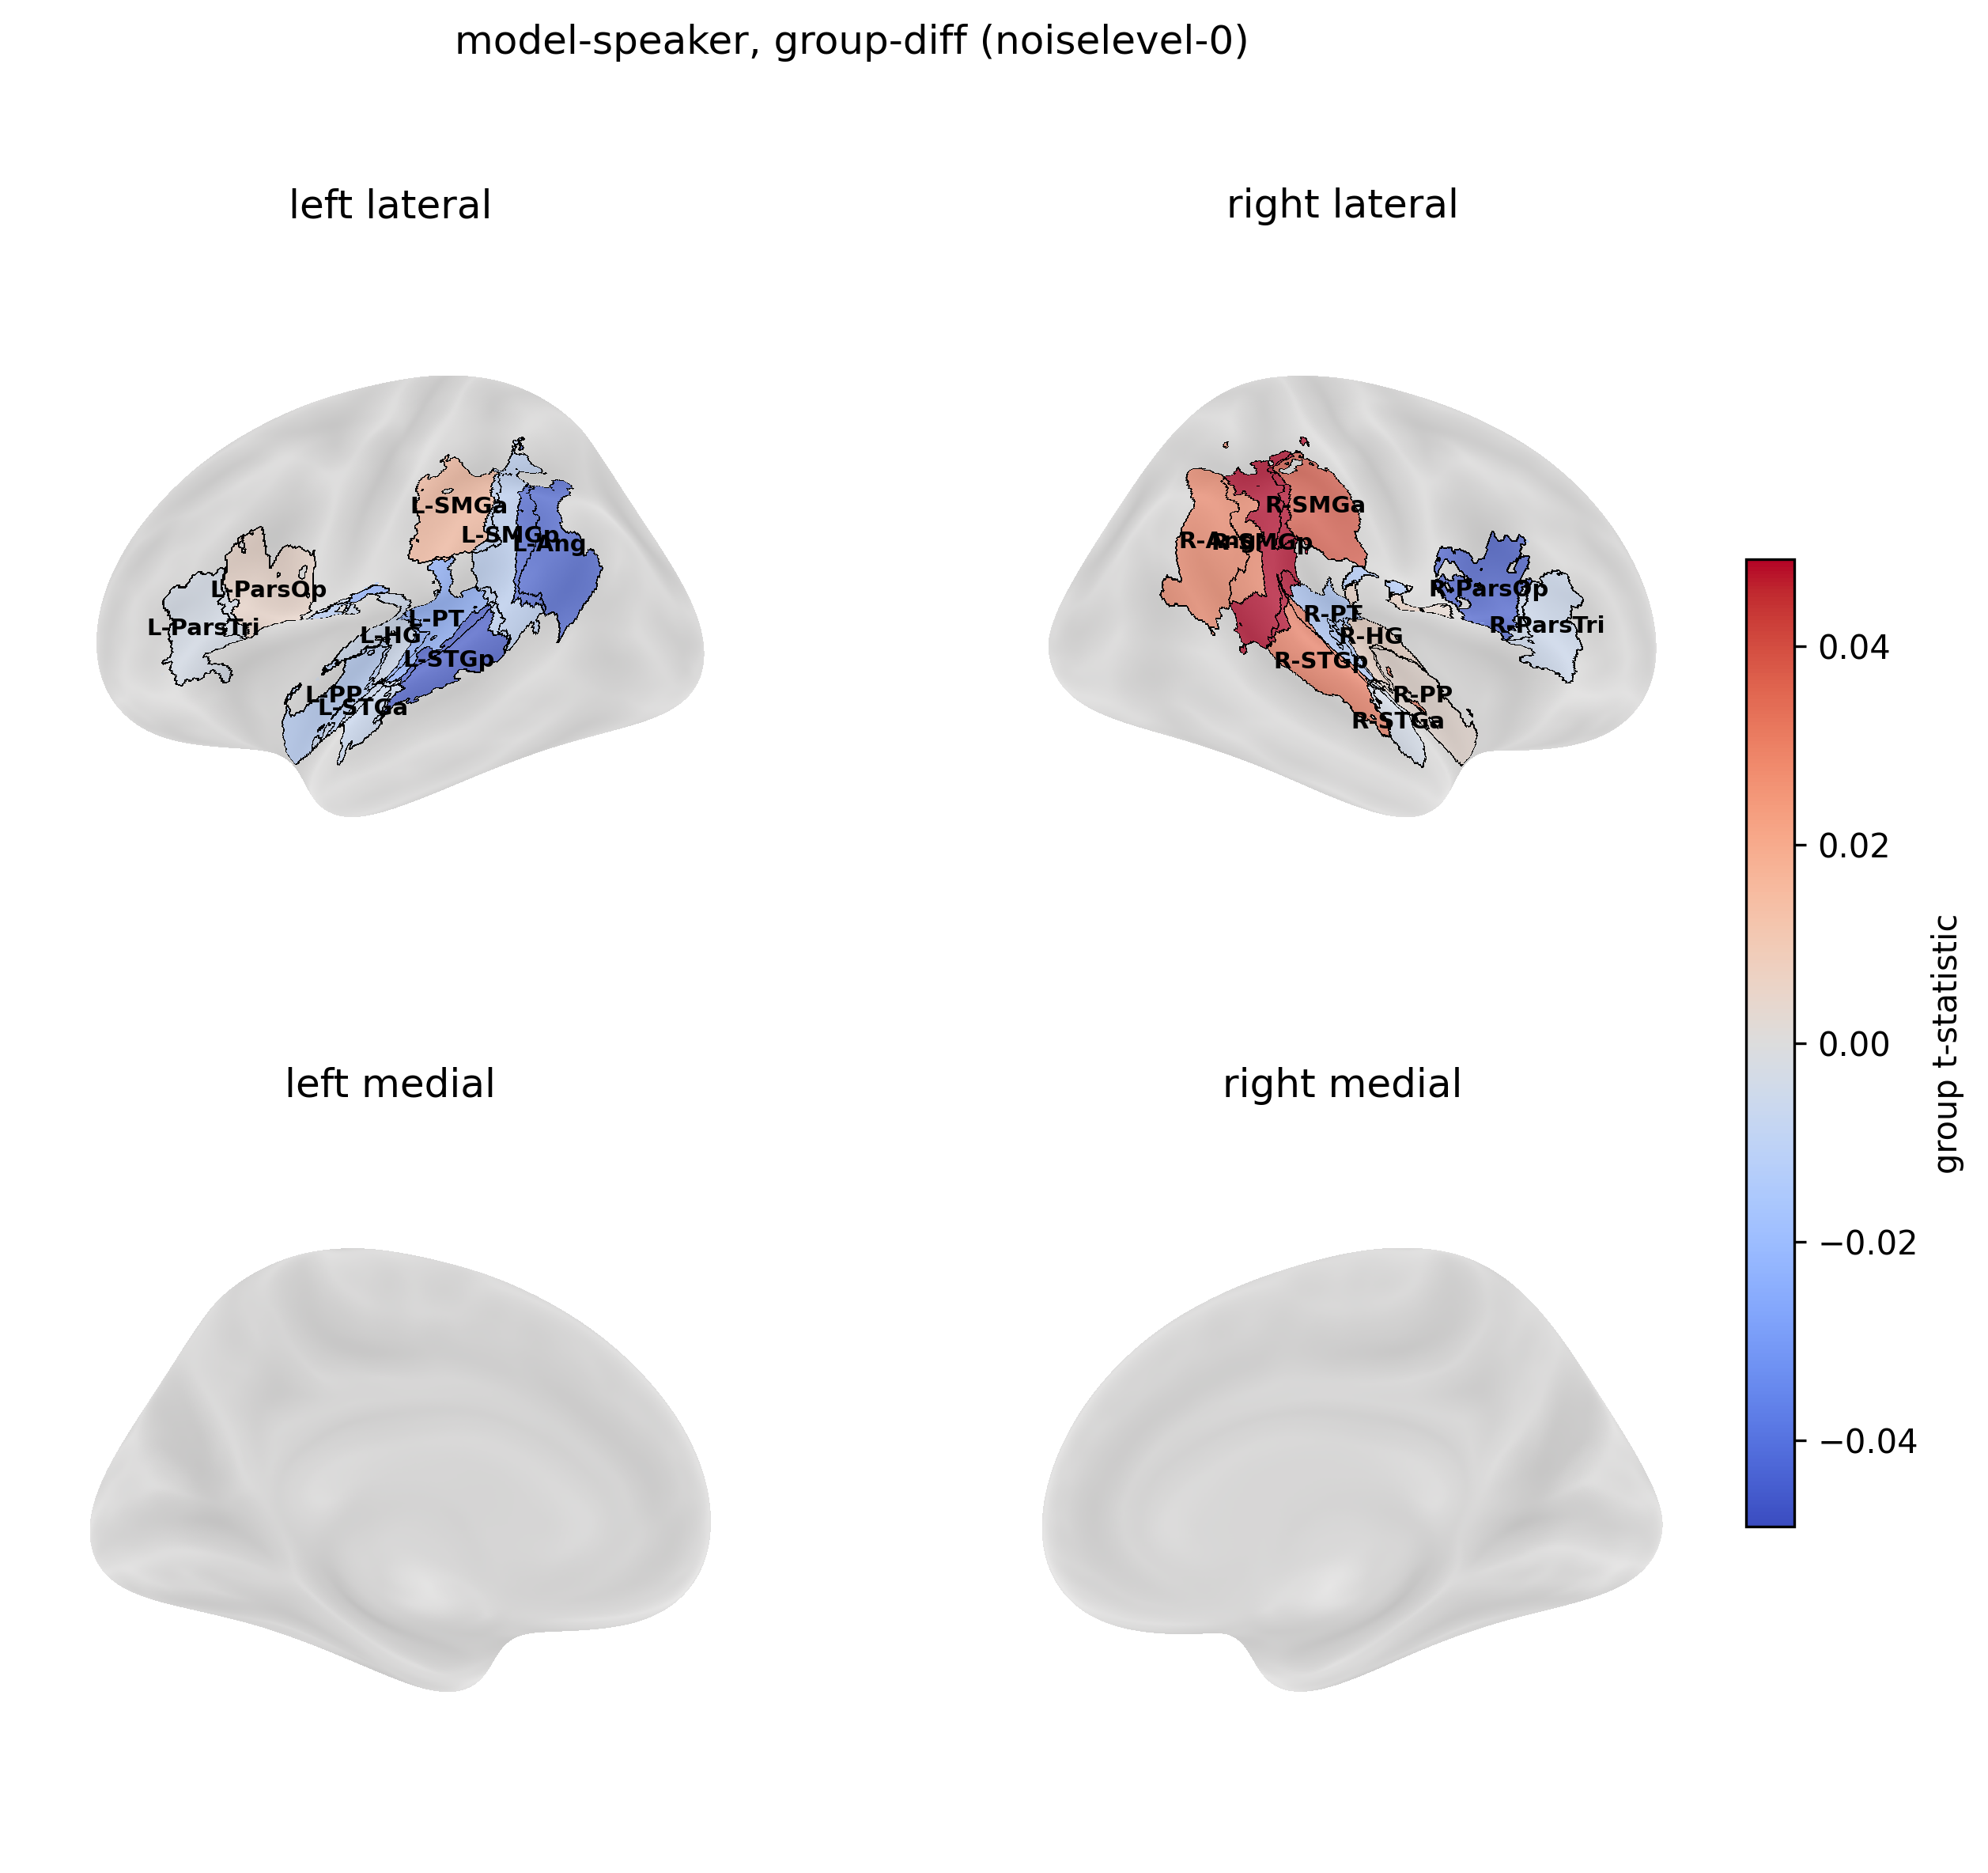

In [18]:
for model_name, stat_dicts in stat_dicts_by_model.items():
    plot_and_save_surface(model_name, 'diff', stat_dicts['diff'])

### Summary

In [19]:
print(f'Model-fit scalars: {len(model_fit_df)} rows -> '
     f'{os.path.join(out_dir, f"model_fit_scalars_noiselevel-{NOISE_LEVEL_TAG}.csv")}')
print(f'Group comparison (bootstrap): {len(group_comparison_df)} ROI x model tests -> '
     f'{os.path.join(out_dir, f"group_comparison_bootstrap_noiselevel-{NOISE_LEVEL_TAG}.csv")}')
print(f'Within-group significance (bootstrap): {len(within_group_significance_df)} ROI x model x group tests -> '
     f'{os.path.join(out_dir, f"within_group_significance_noiselevel-{NOISE_LEVEL_TAG}.csv")}')
print(f'Direct mean-RDM comparison: {len(mean_rdm_df)} ROIs -> '
     f'{os.path.join(out_dir, f"mean_rdm_comparison_noiselevel-{NOISE_LEVEL_TAG}.csv")}')
print(f'Boxplots and surface brain plots saved to {out_dir}')
print()
print('Uncorrected (deliberately -- see top of notebook) significant between-group tests, p < 0.05:')
print(group_comparison_df[group_comparison_df.p_value < 0.05].sort_values('p_value'))
print()
print('Uncorrected within-group significant tests, p < 0.05:')
print(within_group_significance_df[within_group_significance_df.p_value < 0.05].sort_values('p_value'))

Model-fit scalars: 1200 rows -> /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/glmsingle/rsa-group_glmsingle/model_fit_scalars_noiselevel-0.csv
Group comparison (bootstrap): 40 ROI x model tests -> /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/glmsingle/rsa-group_glmsingle/group_comparison_bootstrap_noiselevel-0.csv
Within-group significance (bootstrap): 80 ROI x model x group tests -> /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/glmsingle/rsa-group_glmsingle/within_group_significance_noiselevel-0.csv
Direct mean-RDM comparison: 20 ROIs -> /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/glmsingle/rsa-group_glmsingle/mean_rdm_comparison_noiselevel-0.csv
Boxplots and surface brain plots saved to /bgfs/bchandrasekaran/krs228/data/SSP/data_bids/derivatives/glmsingle/rsa-group_glmsingle

Uncorrected (deliberately -- see top of notebook) significant between-group tests, p < 0.05:
         ROI     model  n_cws  n_cwns  observed_diff    ci_